# AIoT Project - Feature Engineering

This notebook implements the engineered-feature approach: extract statistical and frequency-domain features from windows, compare all features against selected features, and optionally evaluate combined wrist/chest/ankle sensing.


In [36]:
import os
import sys
from pathlib import Path

# Set random seeds for reproducibility
import random
import numpy as np
np.random.seed(42)
random.seed(42)

# basic data engineering
import pandas as pd
pd.options.mode.copy_on_write = True
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 100

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# db
import pymongo

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time
import logging

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [37]:
time_start = time()

## Load configuration

In [38]:
config_path = os.path.join(os.getcwd(), "config.yml")

if not os.path.exists(config_path):
    logger.error(f"Config file not found at {config_path}")
    logger.info("Copy config.yml.template to config.yml and fill in your settings")
    raise FileNotFoundError(config_path)

try:
    with open(config_path) as file:
        config = yaml.load(file, Loader=yaml.FullLoader)
    logger.info(f"Configuration loaded successfully from {config_path}")
except yaml.YAMLError as e:
    logger.error(f"Failed to parse config.yml: {e}")
    raise

# Validate required config keys
required_keys = ["client", "db", "col", "sliding_window", "filter", "classifier", "fine_tune"]
missing_keys = [key for key in required_keys if key not in config]
if missing_keys:
    logger.error(f"Missing required config keys: {missing_keys}")
    raise KeyError(f"Config missing keys: {missing_keys}")

logger.info("Configuration validation passed")

2026-04-30 17:24:39,916 - INFO - Configuration loaded successfully from /home/manousos_kirkinis/Desktop/Projects/AIIoT-Semester-Project/config.yml
2026-04-30 17:24:39,917 - INFO - Configuration validation passed


In [39]:
try:
    client = pymongo.MongoClient(config["client"], serverSelectionTimeoutMS=5000)
    # Verify connection
    client.admin.command("ping")
    logger.info(f"✓ Connected to MongoDB at {config['client']}")
except pymongo.errors.ConnectionFailure as e:
    logger.error(f"✗ Failed to connect to MongoDB: {e}")
    logger.info("Ensure MongoDB is running: mongod or mongodump service")
    raise
except Exception as e:
    logger.error(f"✗ Unexpected error connecting to MongoDB: {e}")
    raise

2026-04-30 17:24:39,934 - INFO - ✓ Connected to MongoDB at mongodb://localhost:27017/


In [40]:
db = client[config["db"]]
coll = db[config["col"]]

## Load data

Fetch the documents that correspond to the **sensor configuration you are evaluating**. Start with the **Protocol** split and the hand/wrist IMU in the AccGyr configuration.

```python
query = {"split": "Protocol", "imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))
```

The Optional split is useful for extra EDA, but several optional activities appear only for a subset of subjects. For the baseline model, Protocol is cleaner because every Protocol class has subject-disjoint train/test coverage.

Carry the `subject` field through every transformation (windowing, filtering, feature extraction) because the train/test split must be subject-disjoint.

In [41]:
found_labels = coll.distinct("activity_label", {"split": "Protocol"})
print("Protocol activities in DB:", sorted(found_labels))

Protocol activities in DB: ['Nordic walking', 'ascending stairs', 'cycling', 'descending stairs', 'ironing', 'lying', 'rope jumping', 'running', 'sitting', 'standing', 'vacuum cleaning', 'walking']


In [42]:
query = {"split": "Protocol", "imu_location": "hand", "sensor": "AccGyr"}
documents = list(coll.find(query))

In [43]:
print(f"Loaded documents: {len(documents)}")

if len(documents) > 0:
    example = documents[0]
    print("Example document keys:", sorted(example.keys()))
    print("Example sensor/imu_location/subject:", example.get("sensor"), example.get("imu_location"), example.get("subject"))

segments_df = pd.DataFrame([
    {
        "activity_label": doc["activity_label"],
        "activity_id": doc["activity_id"],
        "subject": doc["subject"],
        "imu_location": doc["imu_location"],
        "sensor": doc["sensor"],
        "segment_length": len(doc["data"]["acc_x"]),
        "sr": doc.get("sr", 100),
    }
    for doc in documents
])
segments_df["duration_sec"] = segments_df["segment_length"] / segments_df["sr"]
segments_df.head()

Loaded documents: 107
Example document keys: ['_id', 'activity_id', 'activity_label', 'data', 'datetime', 'imu_location', 'segment_index', 'segment_length', 'sensor', 'split', 'sr', 'subject']
Example sensor/imu_location/subject: AccGyr hand 101


,activity_label,activity_id,subject,imu_location,sensor,segment_length,sr,duration_sec
0,lying,1,101,hand,AccGyr,27187,100,271.87
1,sitting,2,101,hand,AccGyr,23480,100,234.80
2,standing,3,101,hand,AccGyr,21717,100,217.17
3,ironing,17,101,hand,AccGyr,23573,100,235.73
4,vacuum cleaning,16,101,hand,AccGyr,22941,100,229.41


## Explore the nature of the data

Suggested exploratory plots for the PAMAP2 instances you loaded:

* Total recording time per activity (sum of segment lengths in seconds, grouped by `activity_label`).
* A time-domain plot of one segment per activity, so you can see the signal shape of each class.
* The distribution of segment counts per `(subject, activity_label)` pair — this exposes the class imbalance you will need to address.

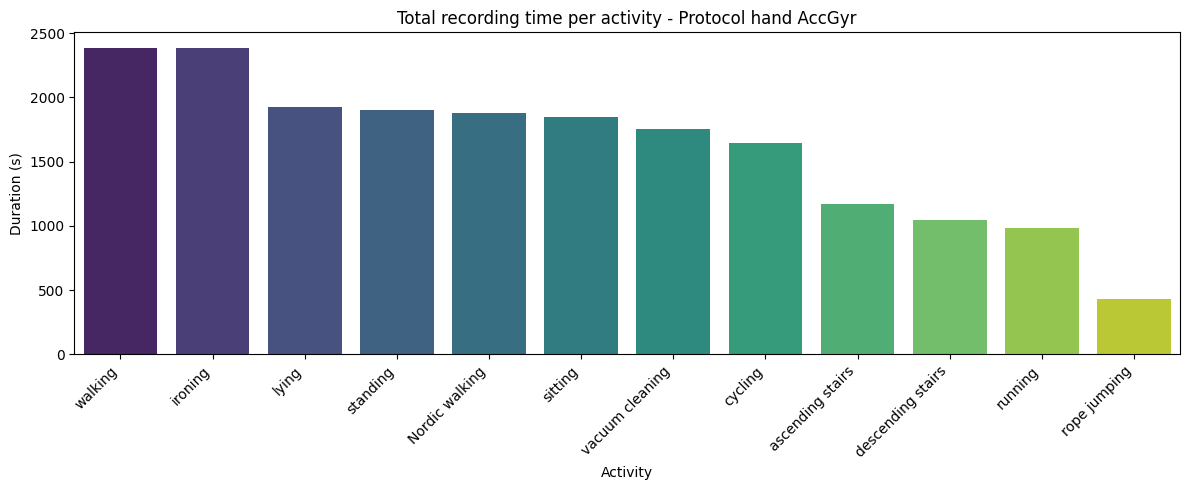

In [44]:
# Total recording time per activity
activity_duration = segments_df.groupby("activity_label")["duration_sec"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=activity_duration.index, y=activity_duration.values, hue=activity_duration.index, palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Total recording time per activity - Protocol hand AccGyr")
plt.ylabel("Duration (s)")
plt.xlabel("Activity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "activity_duration_protocol_hand_accgyr.png", bbox_inches="tight")
plt.show()

<Figure size 1600x600 with 0 Axes>

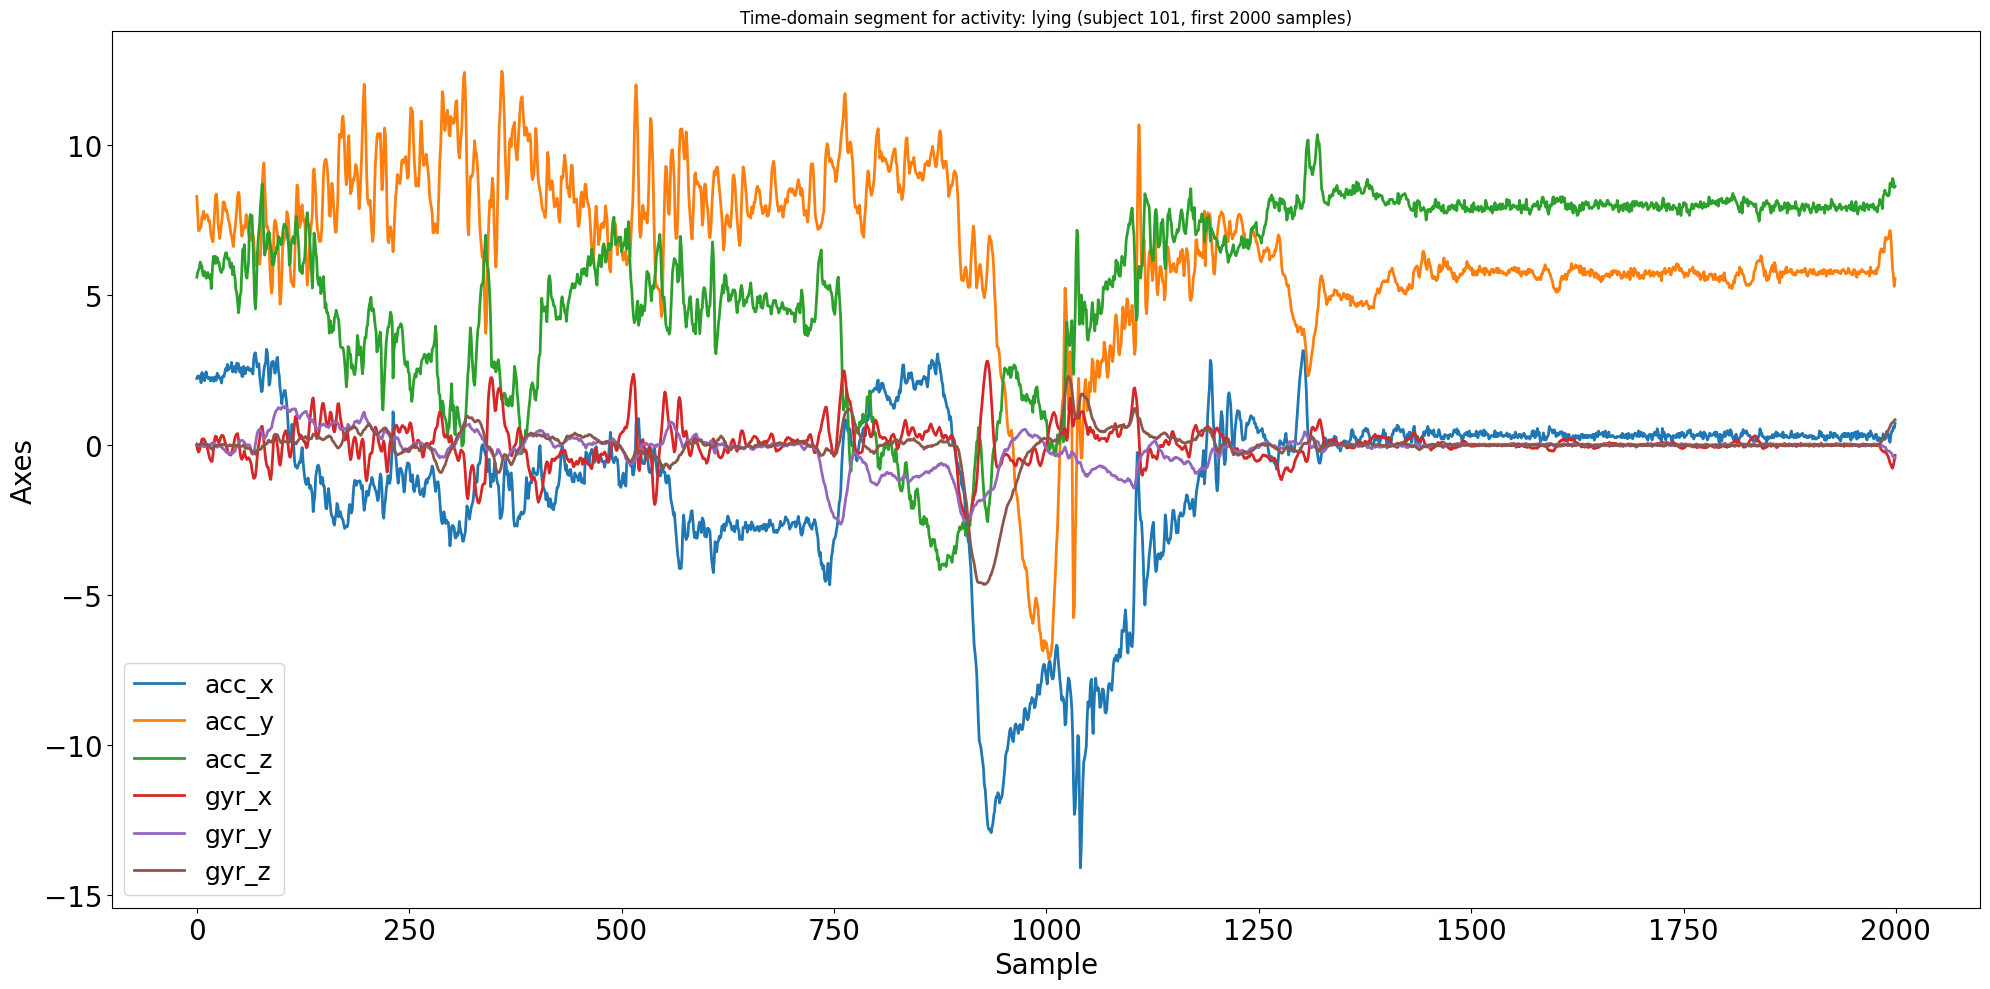

<Figure size 1600x600 with 0 Axes>

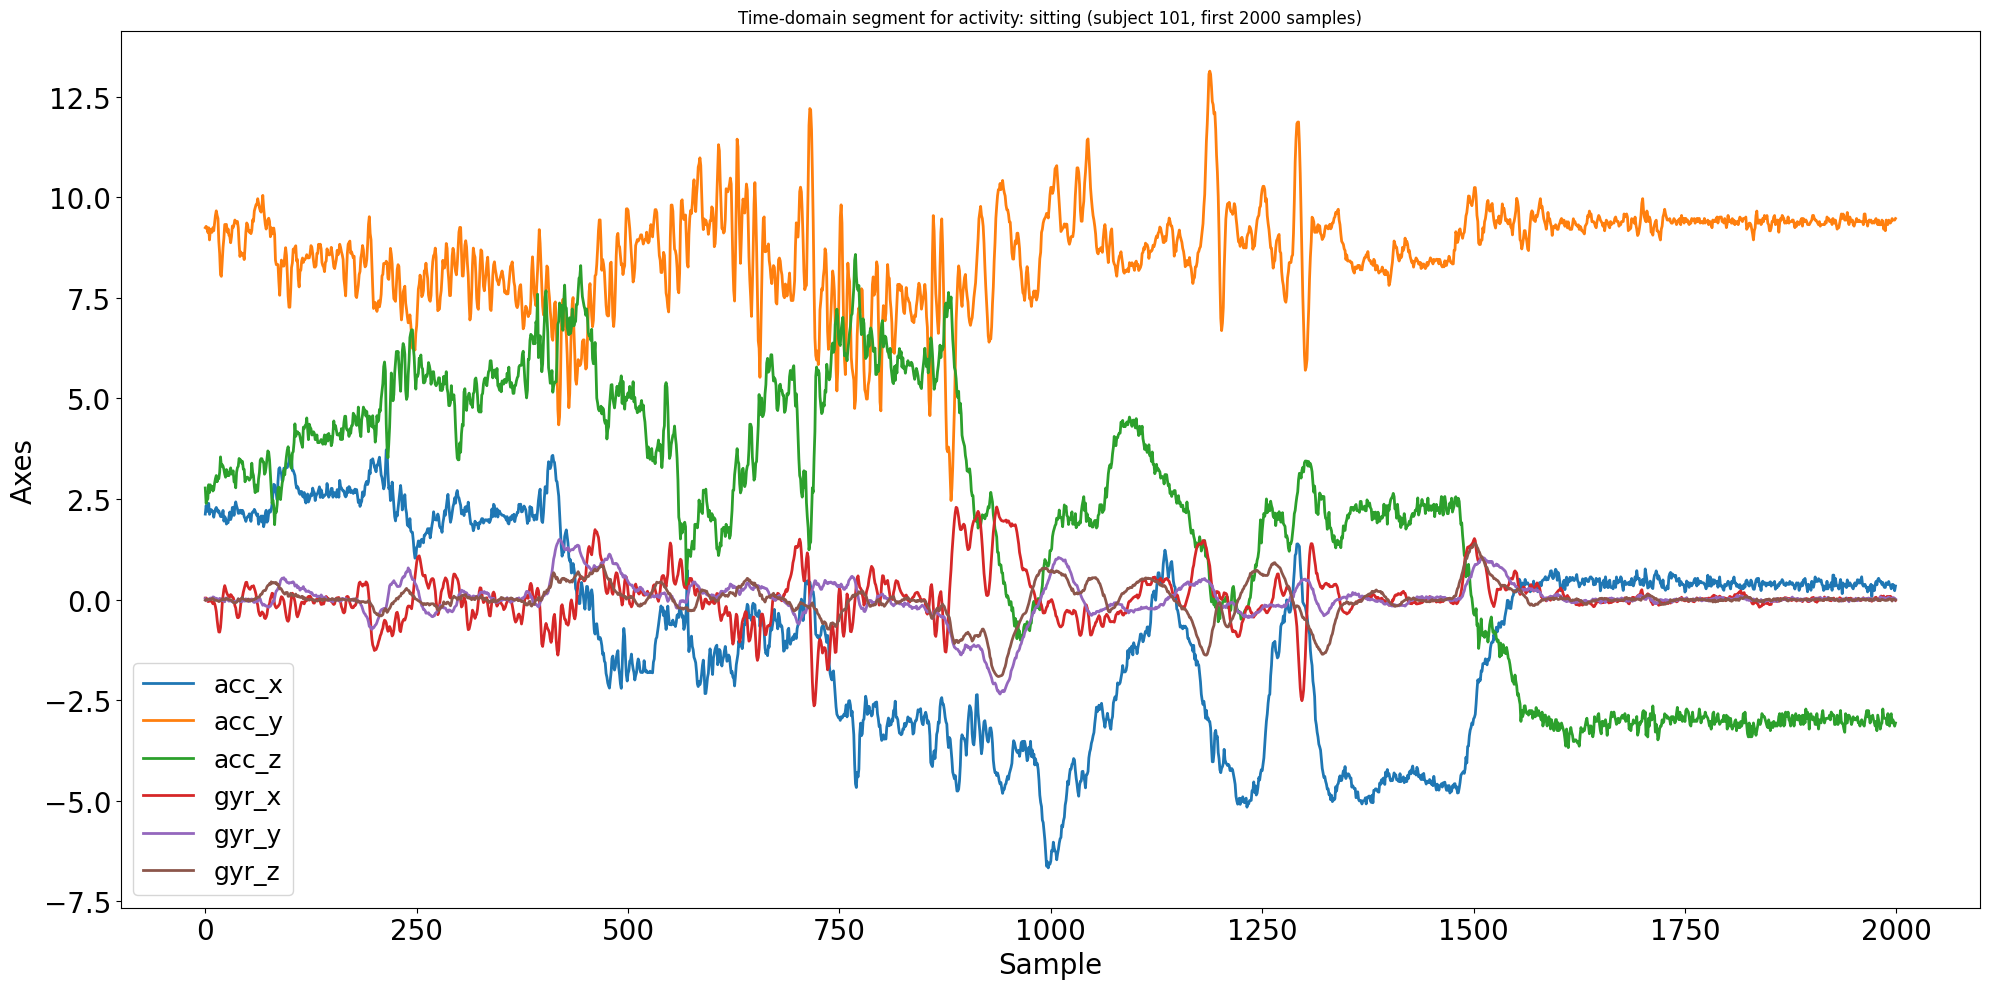

<Figure size 1600x600 with 0 Axes>

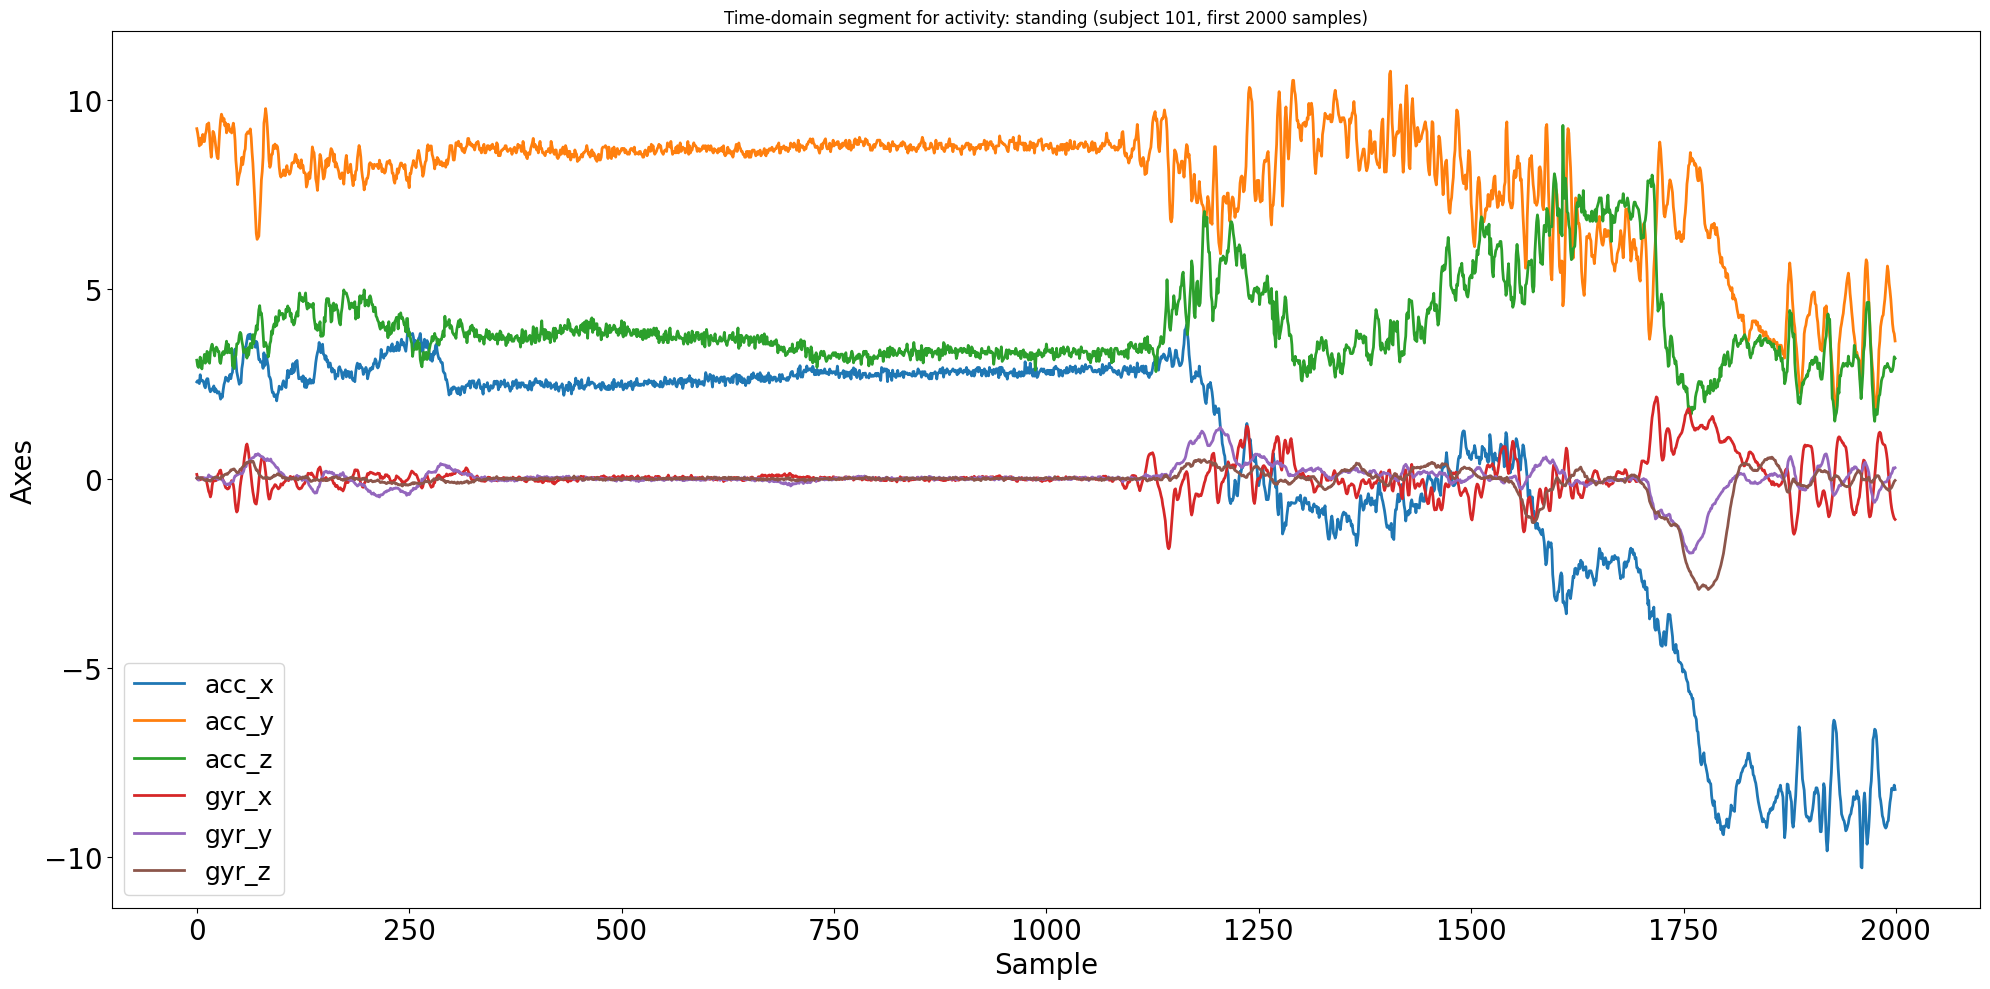

<Figure size 1600x600 with 0 Axes>

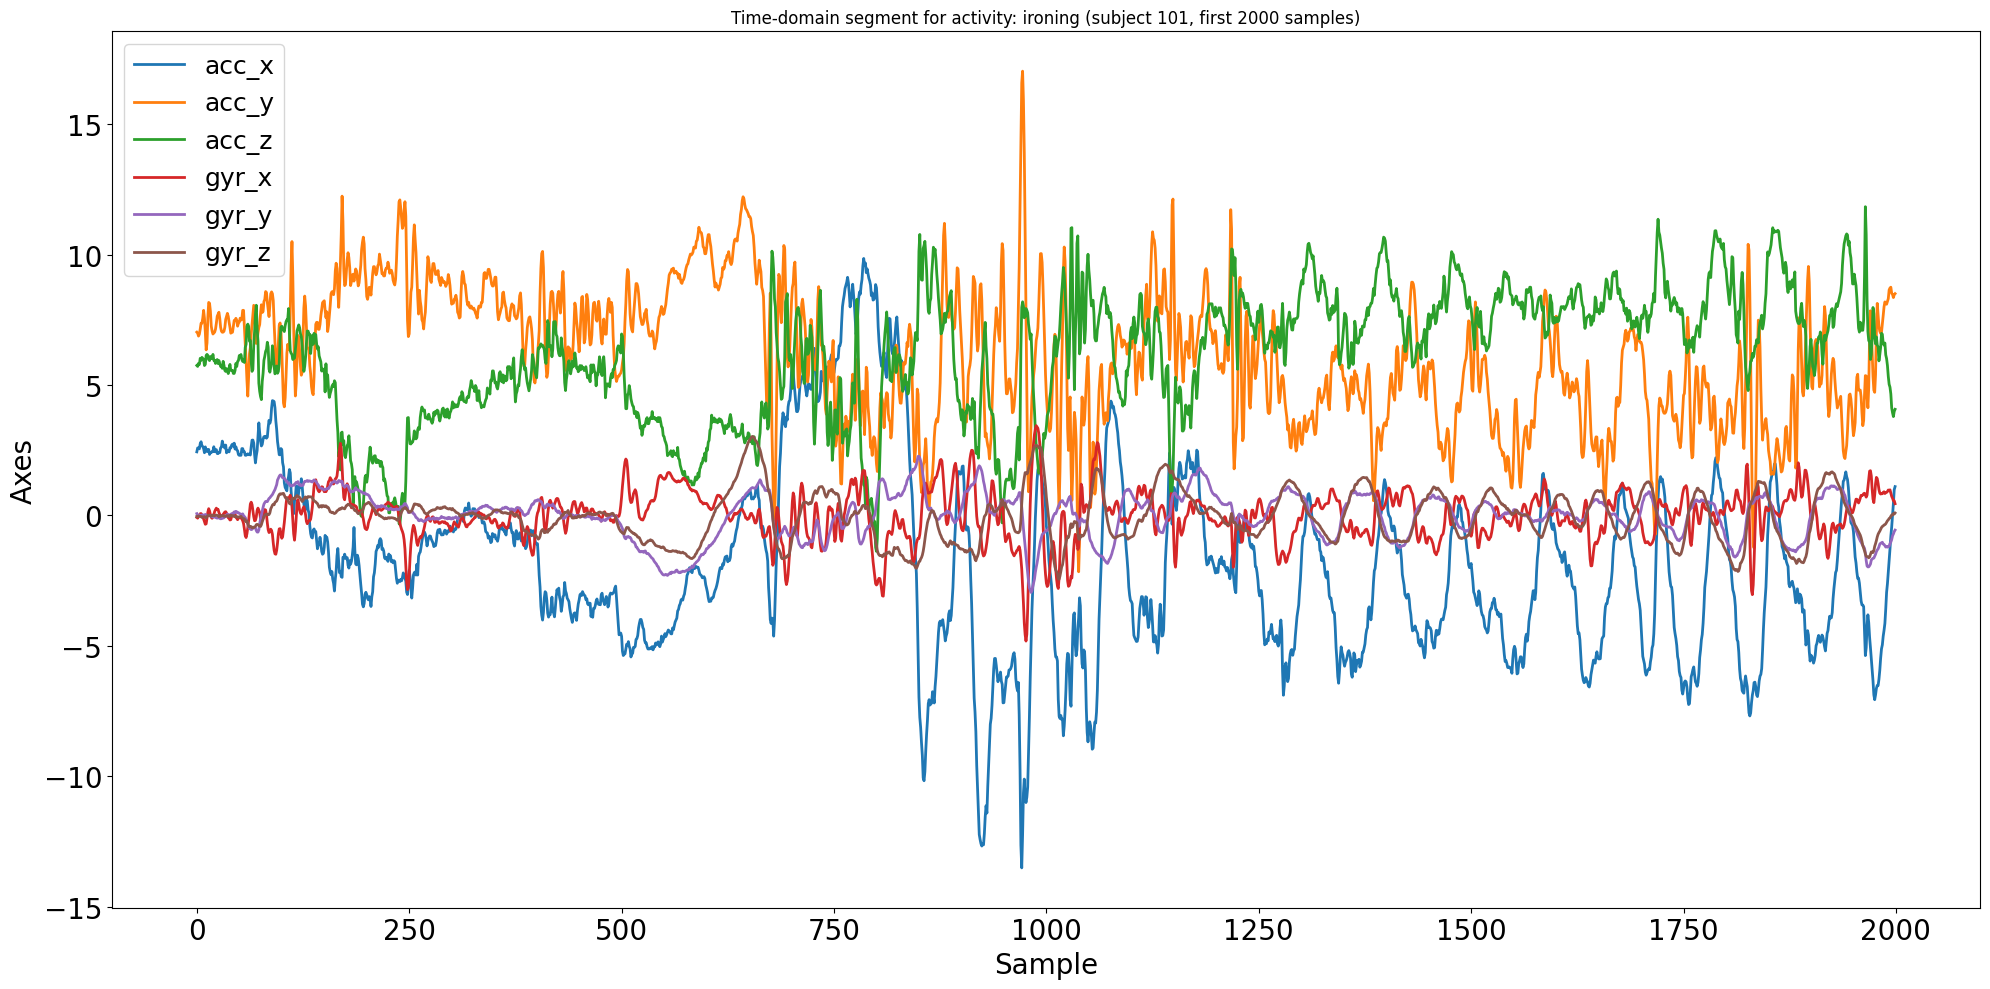

<Figure size 1600x600 with 0 Axes>

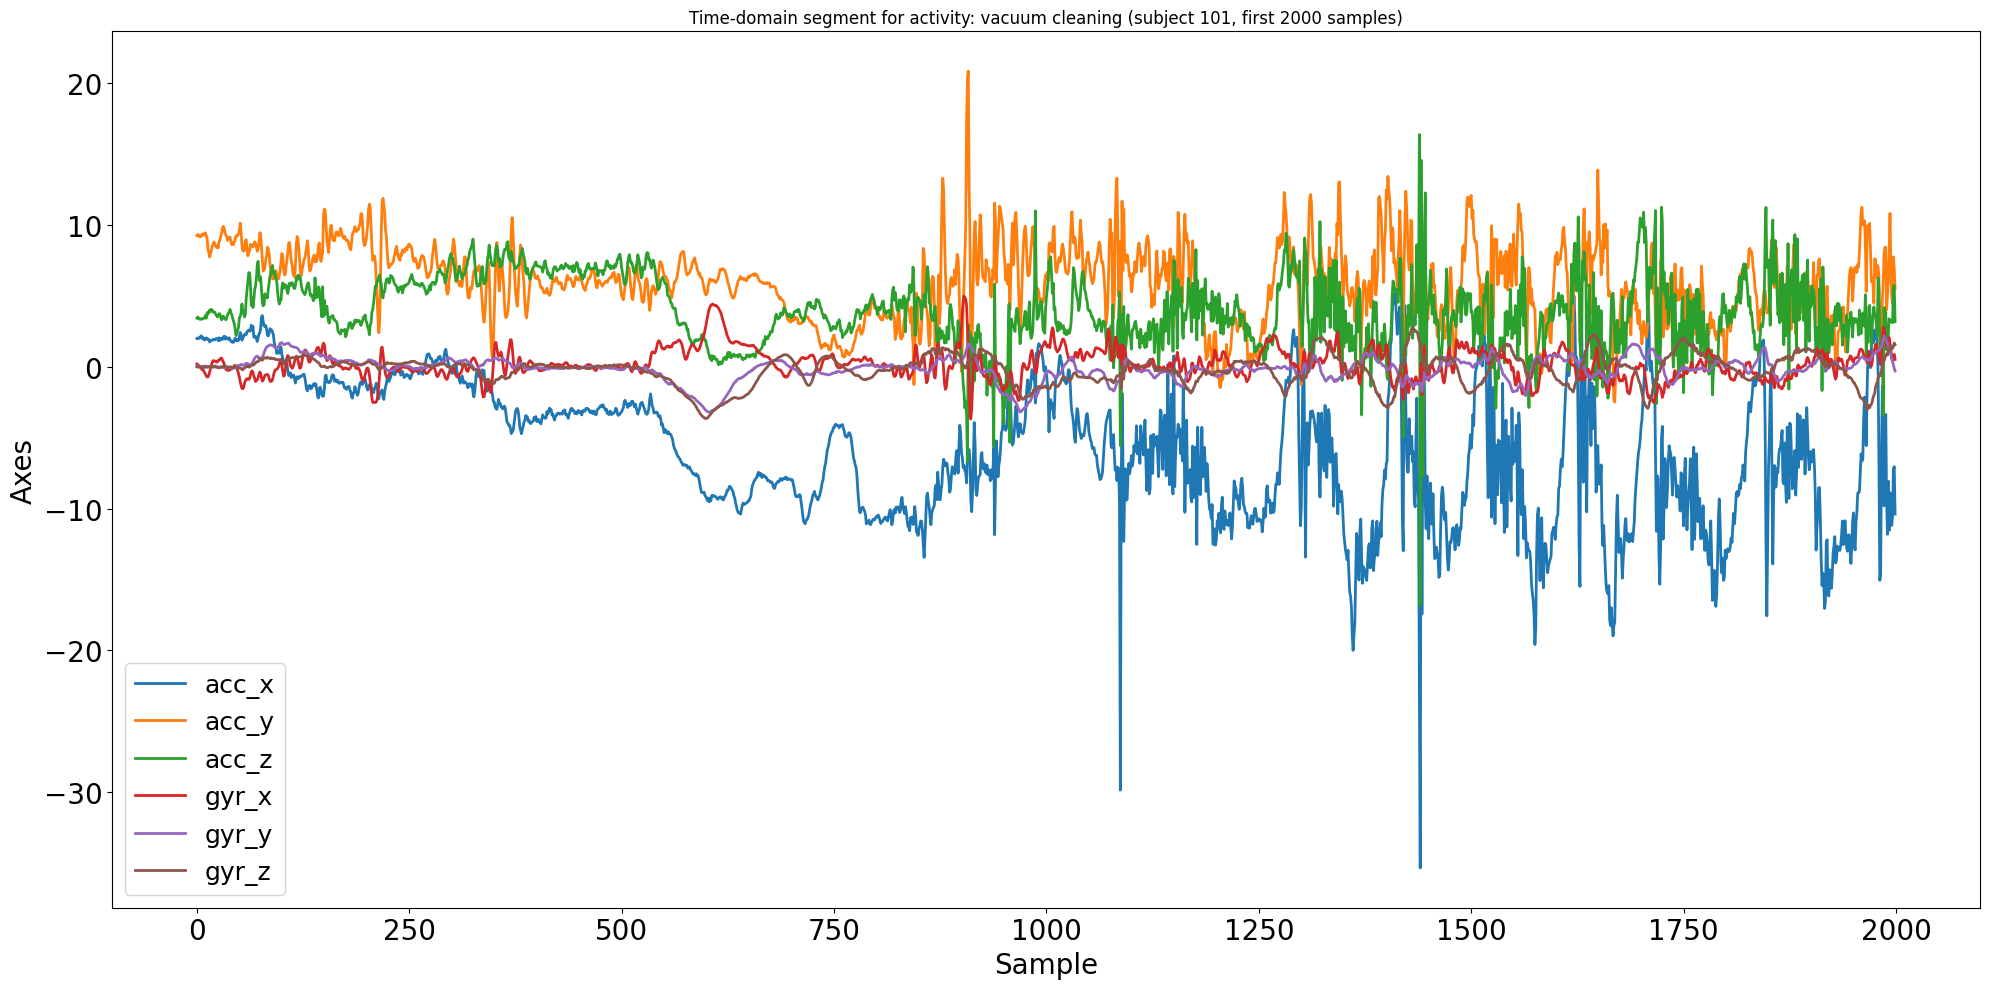

<Figure size 1600x600 with 0 Axes>

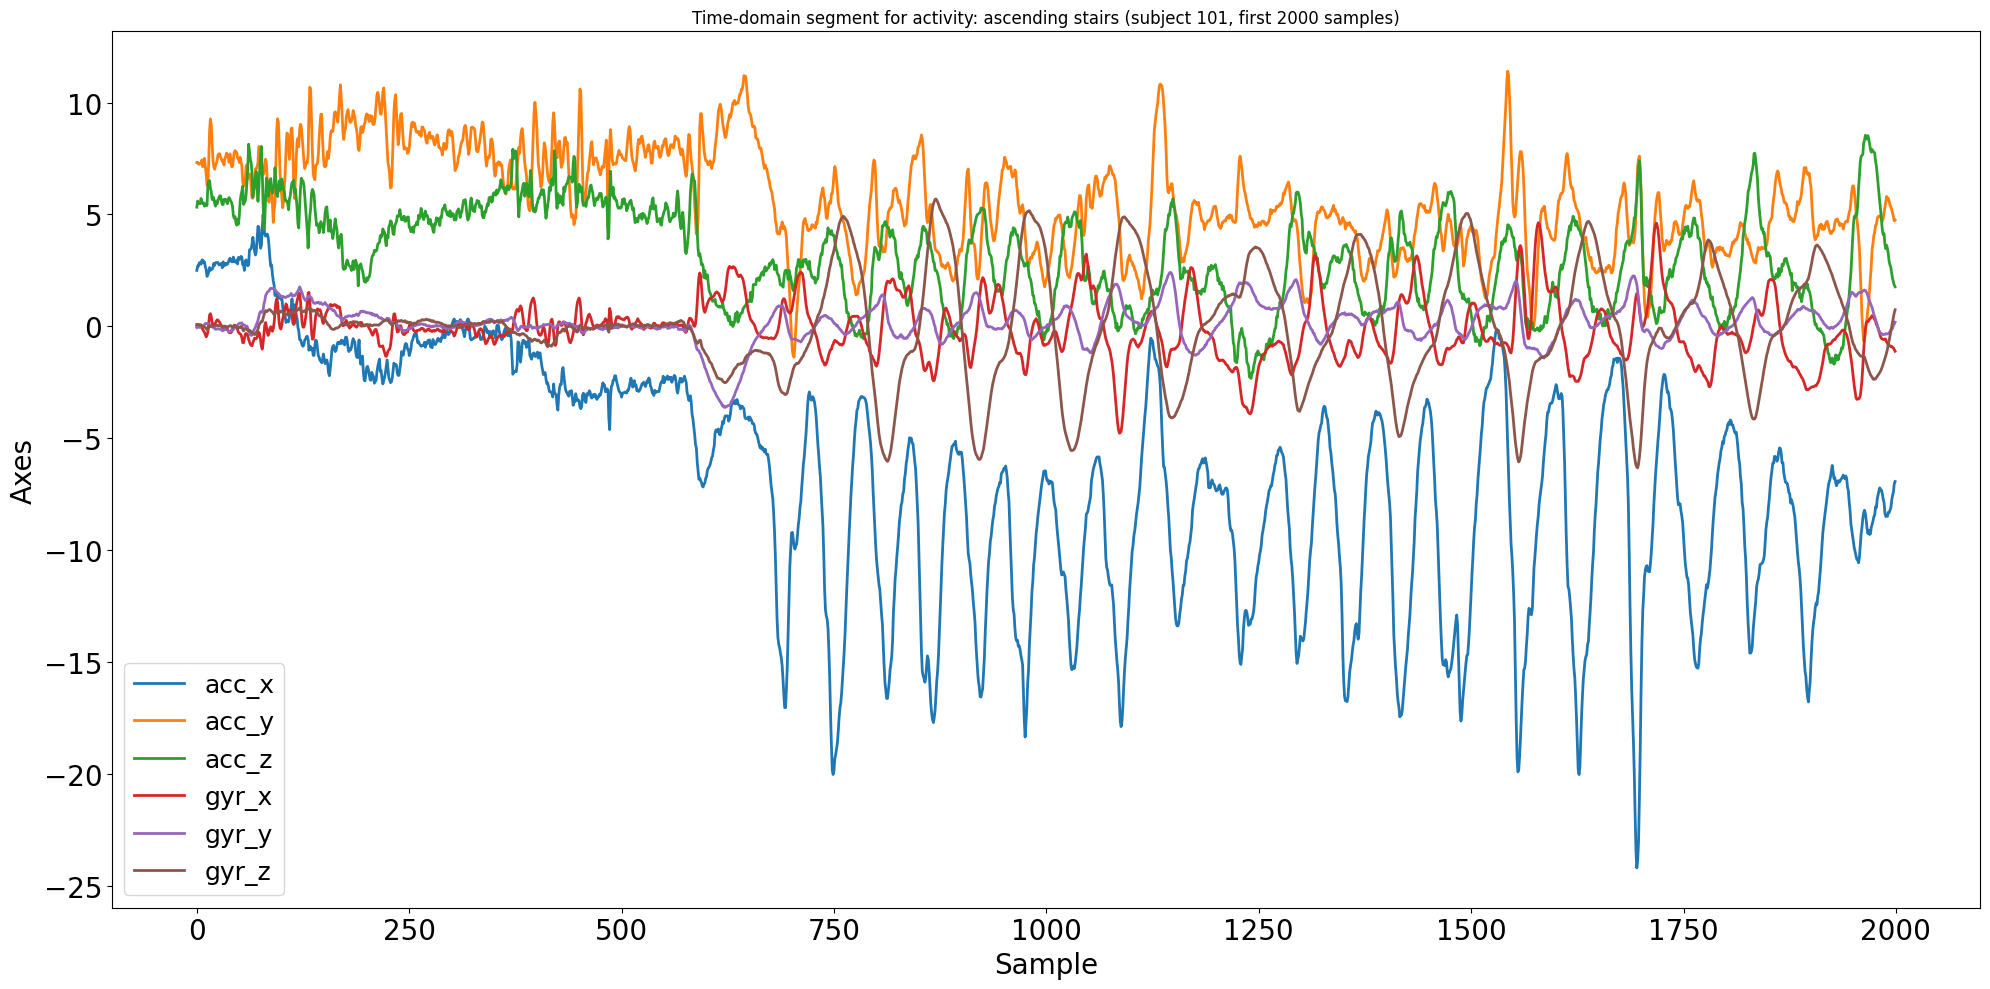

<Figure size 1600x600 with 0 Axes>

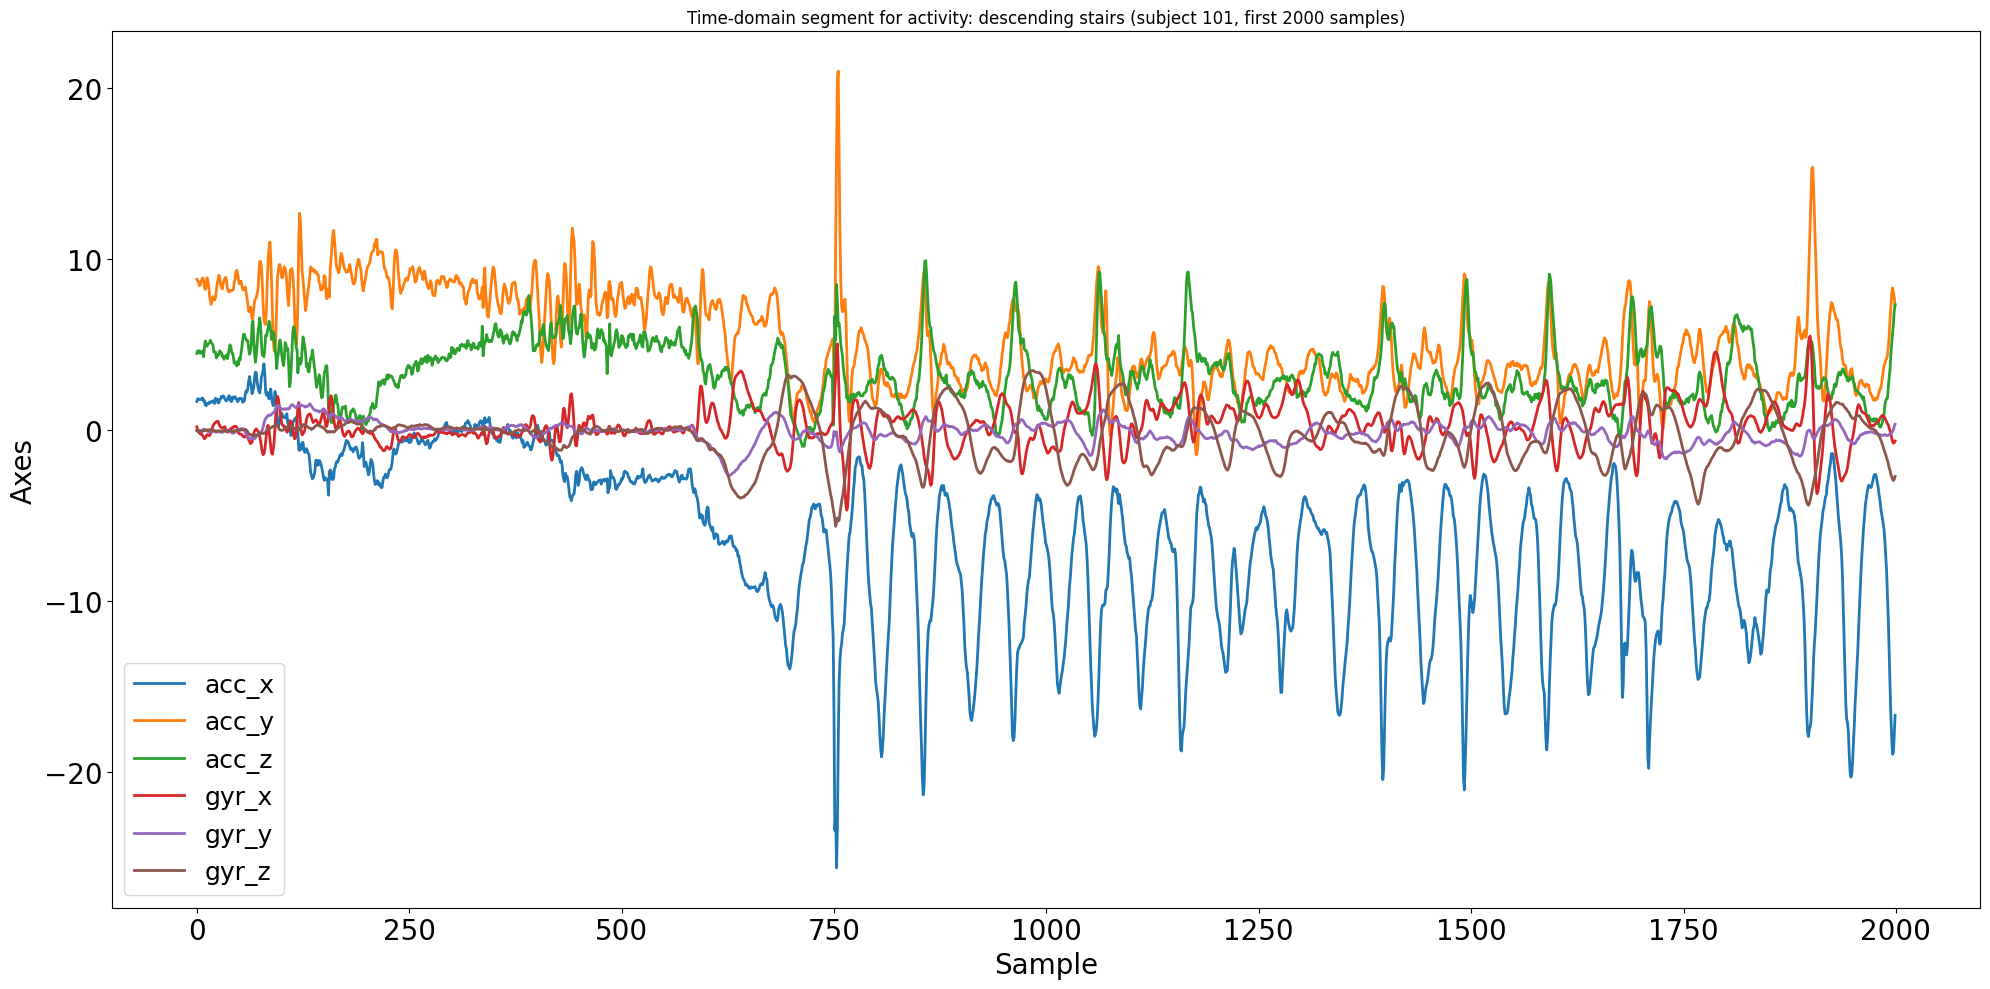

<Figure size 1600x600 with 0 Axes>

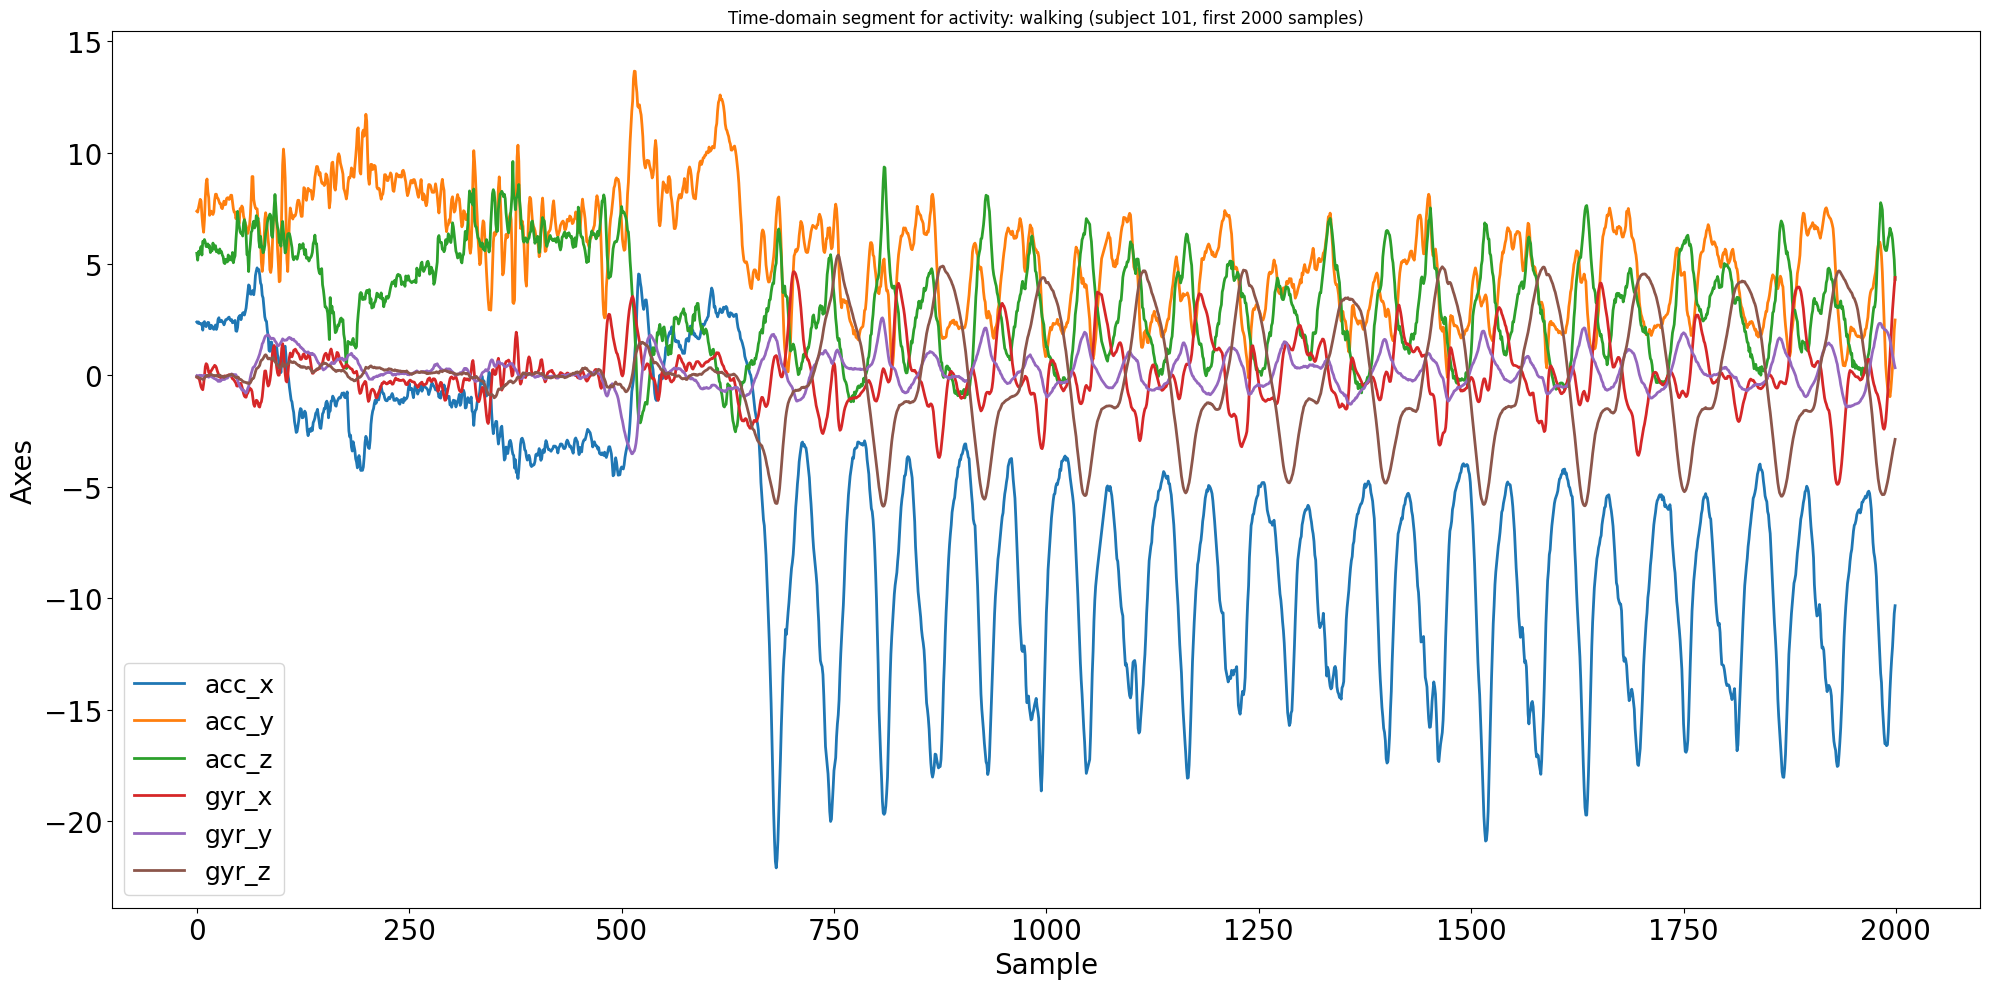

<Figure size 1600x600 with 0 Axes>

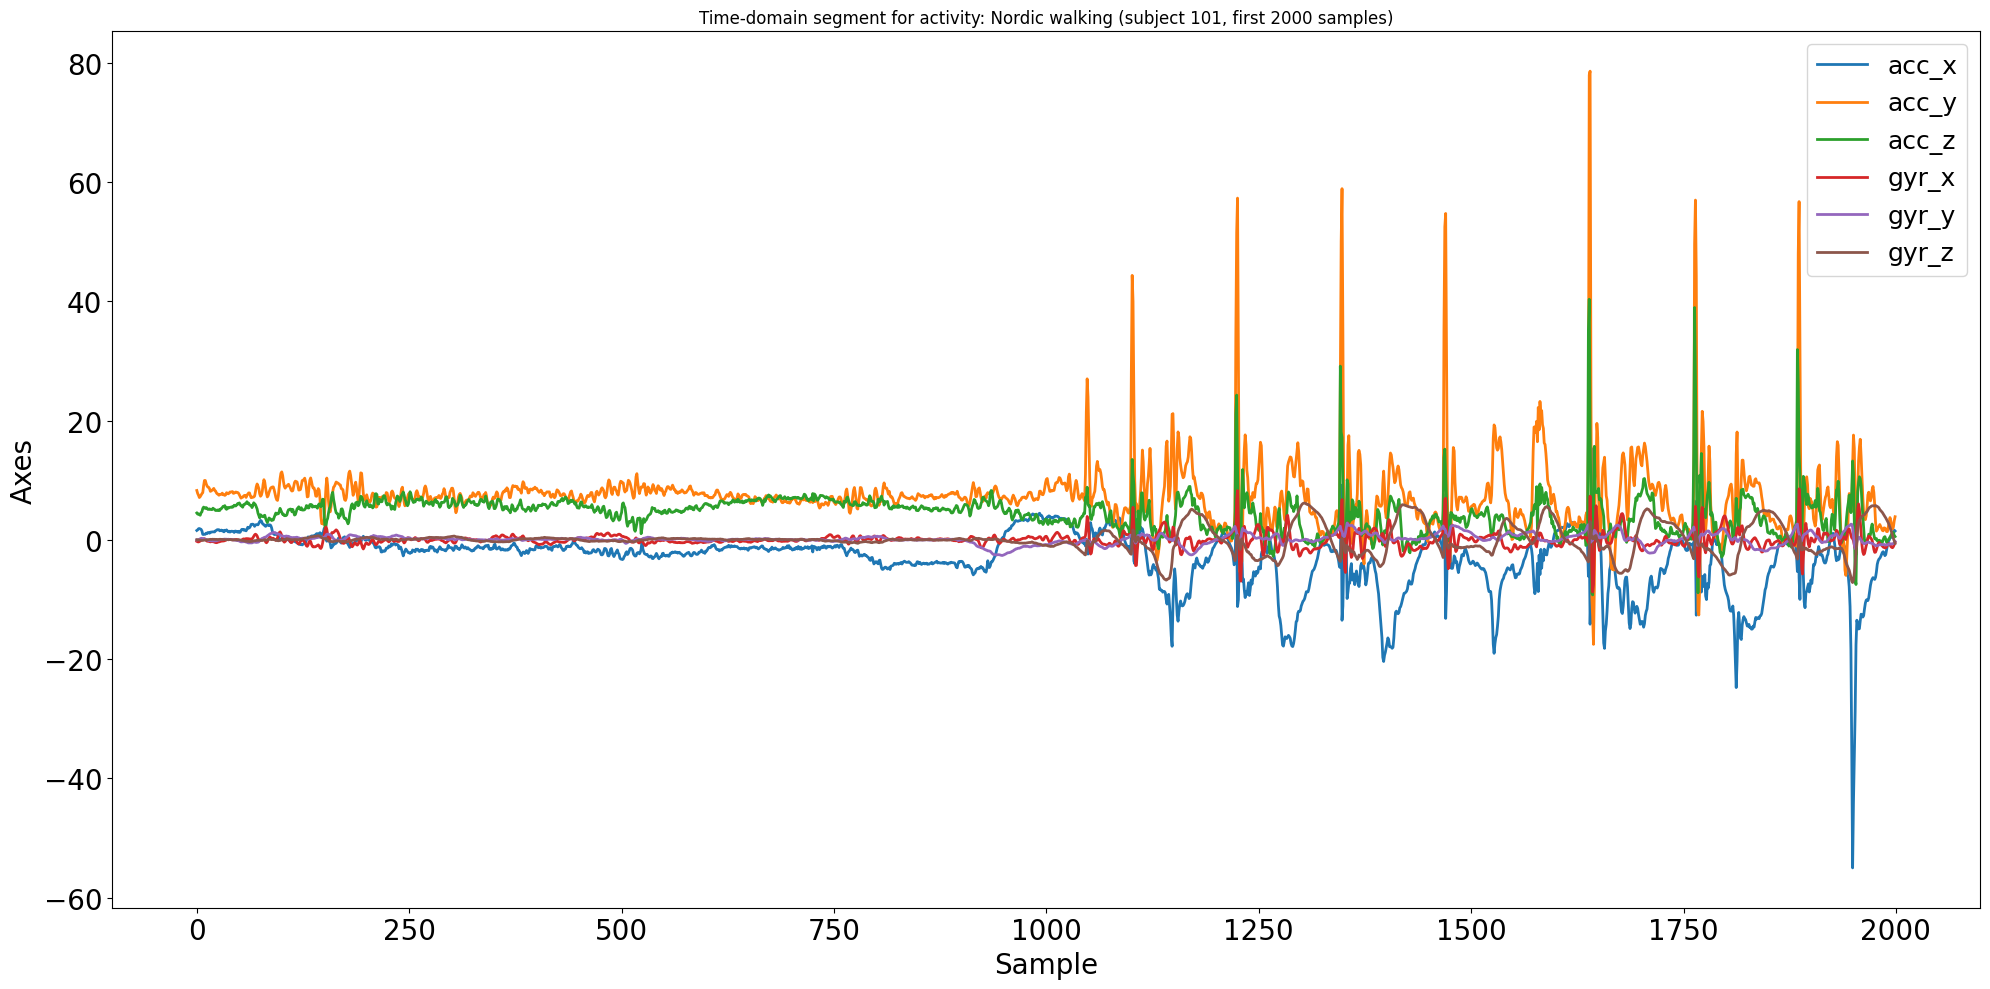

<Figure size 1600x600 with 0 Axes>

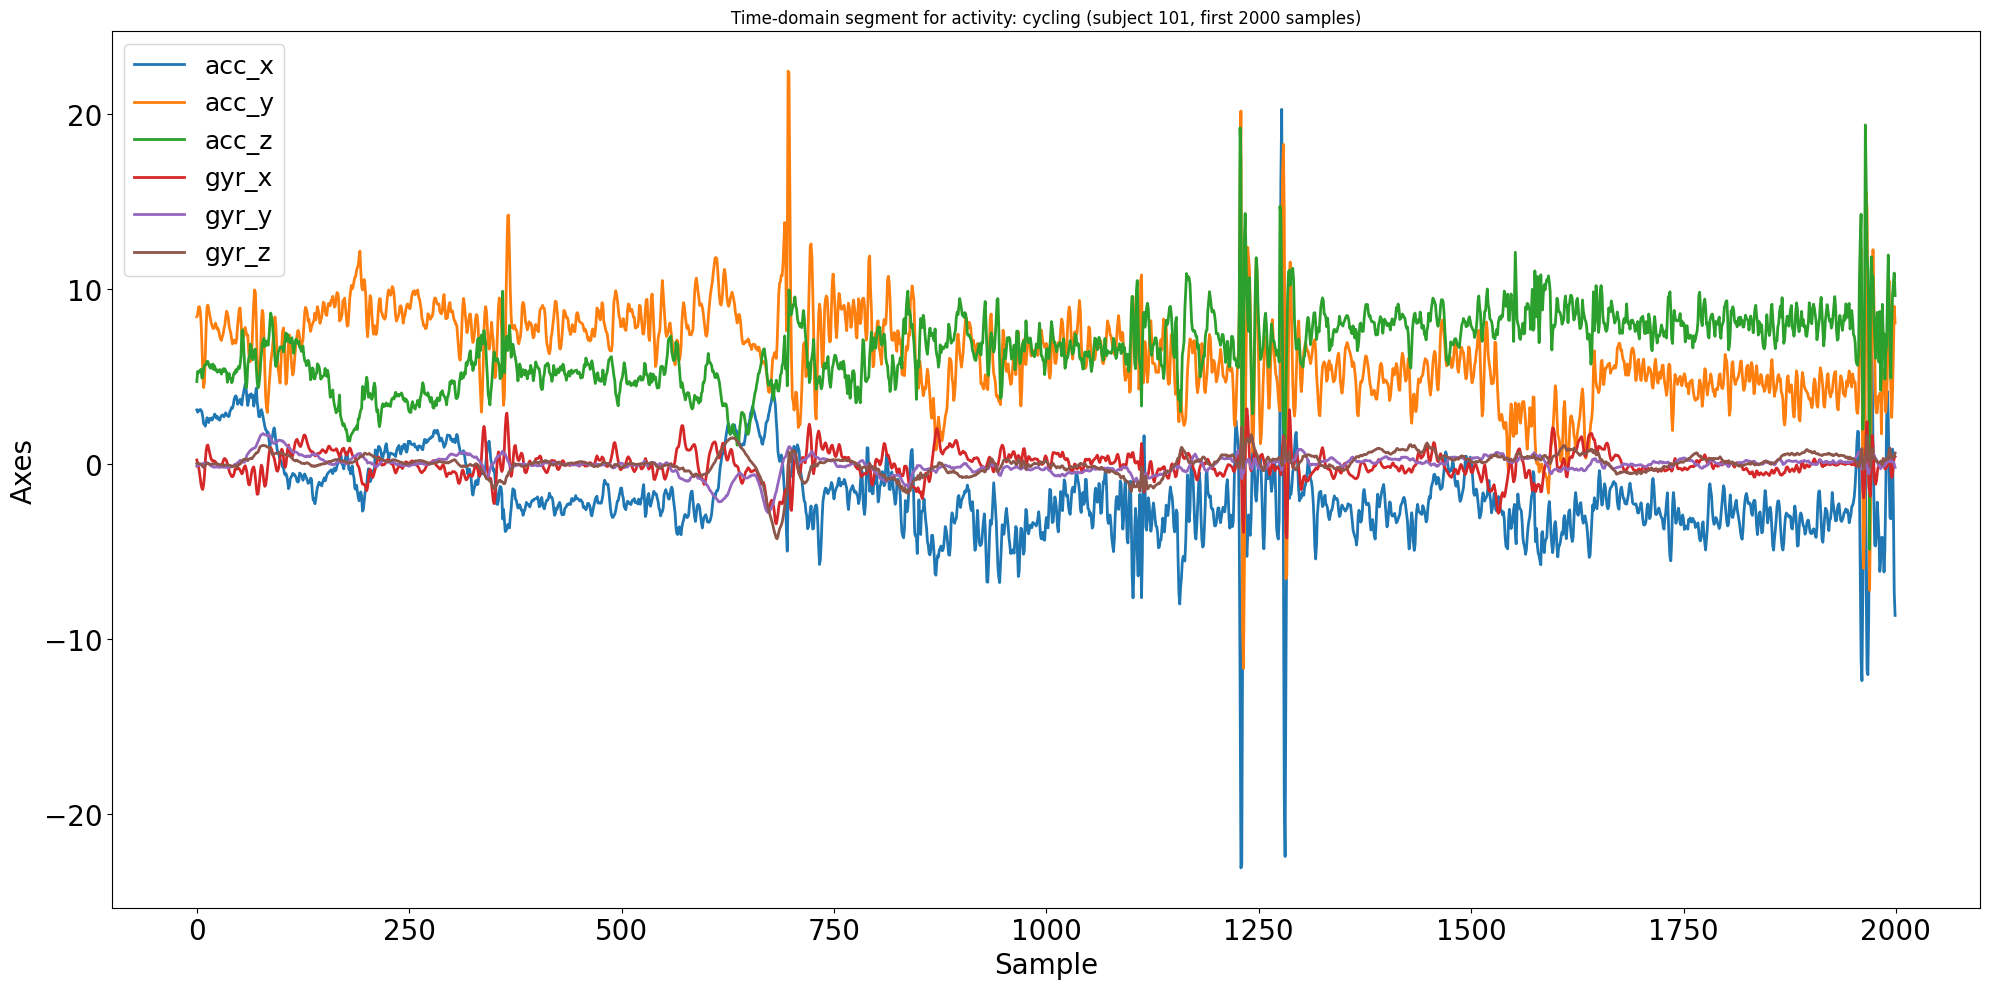

<Figure size 1600x600 with 0 Axes>

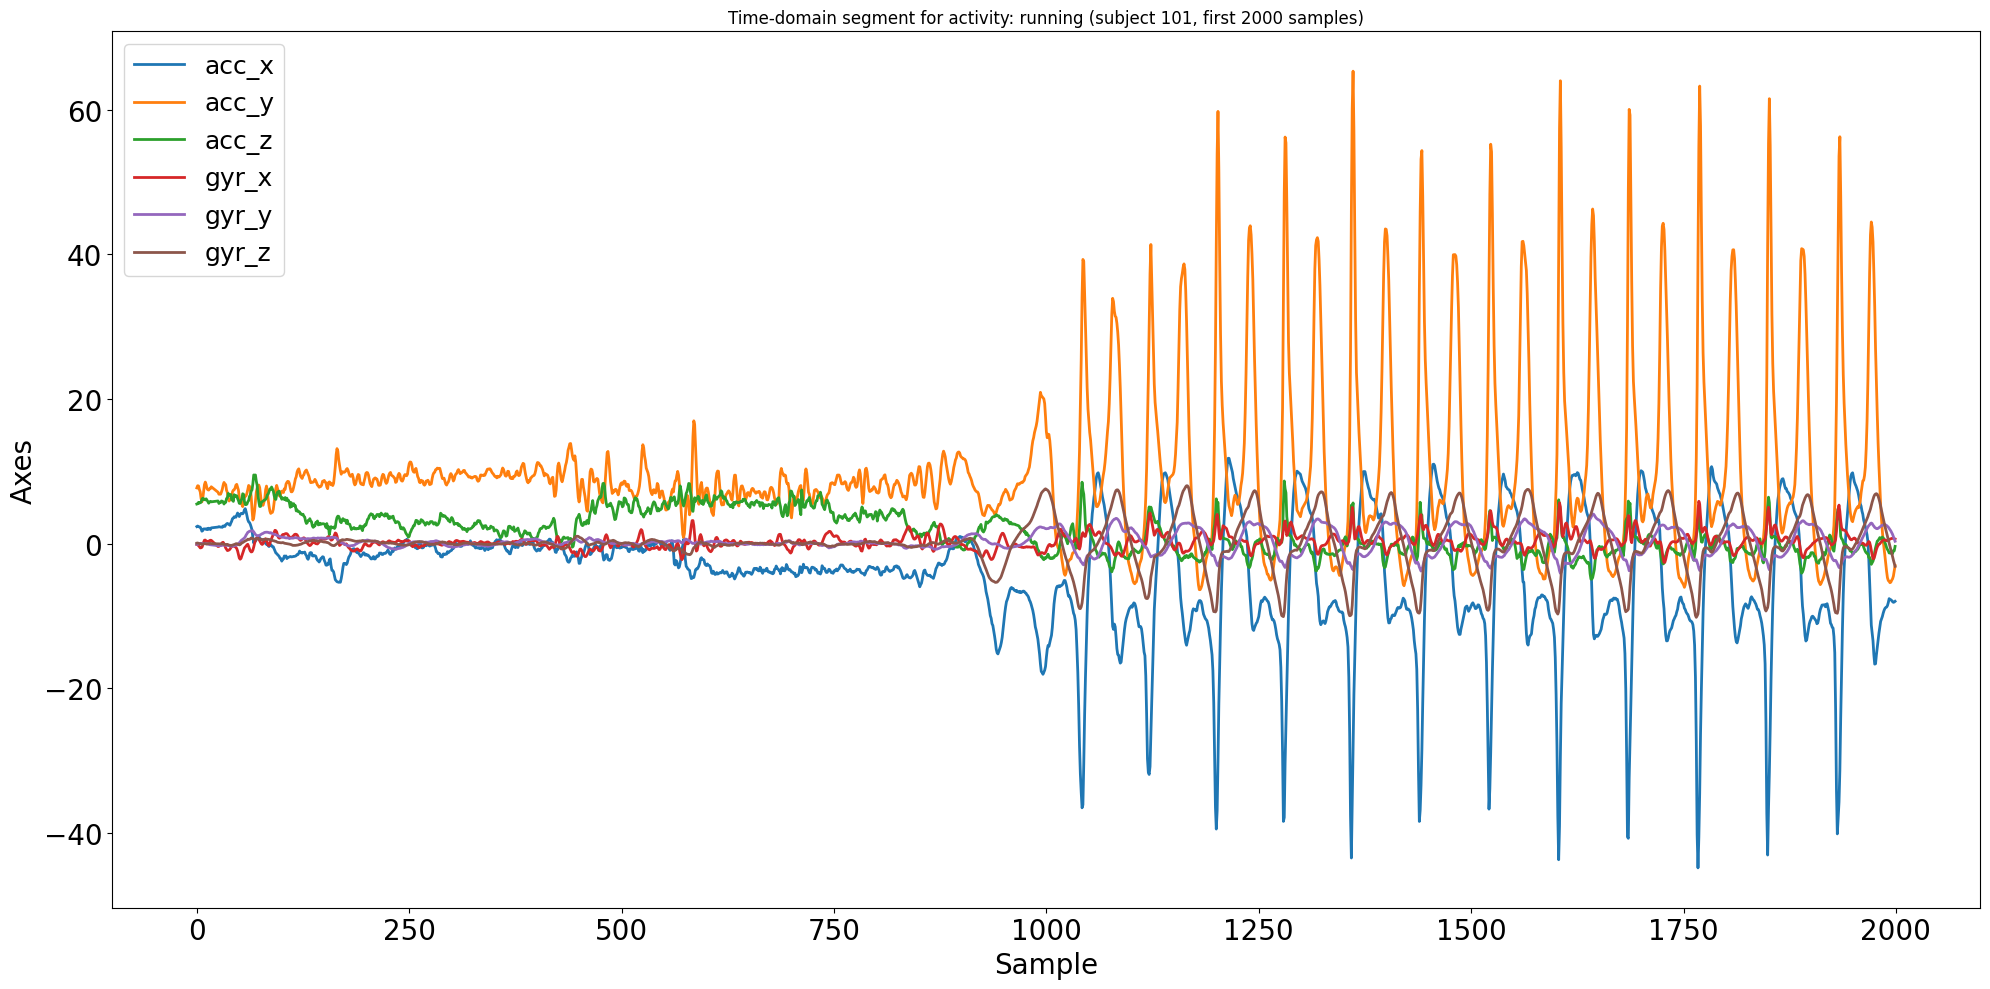

<Figure size 1600x600 with 0 Axes>

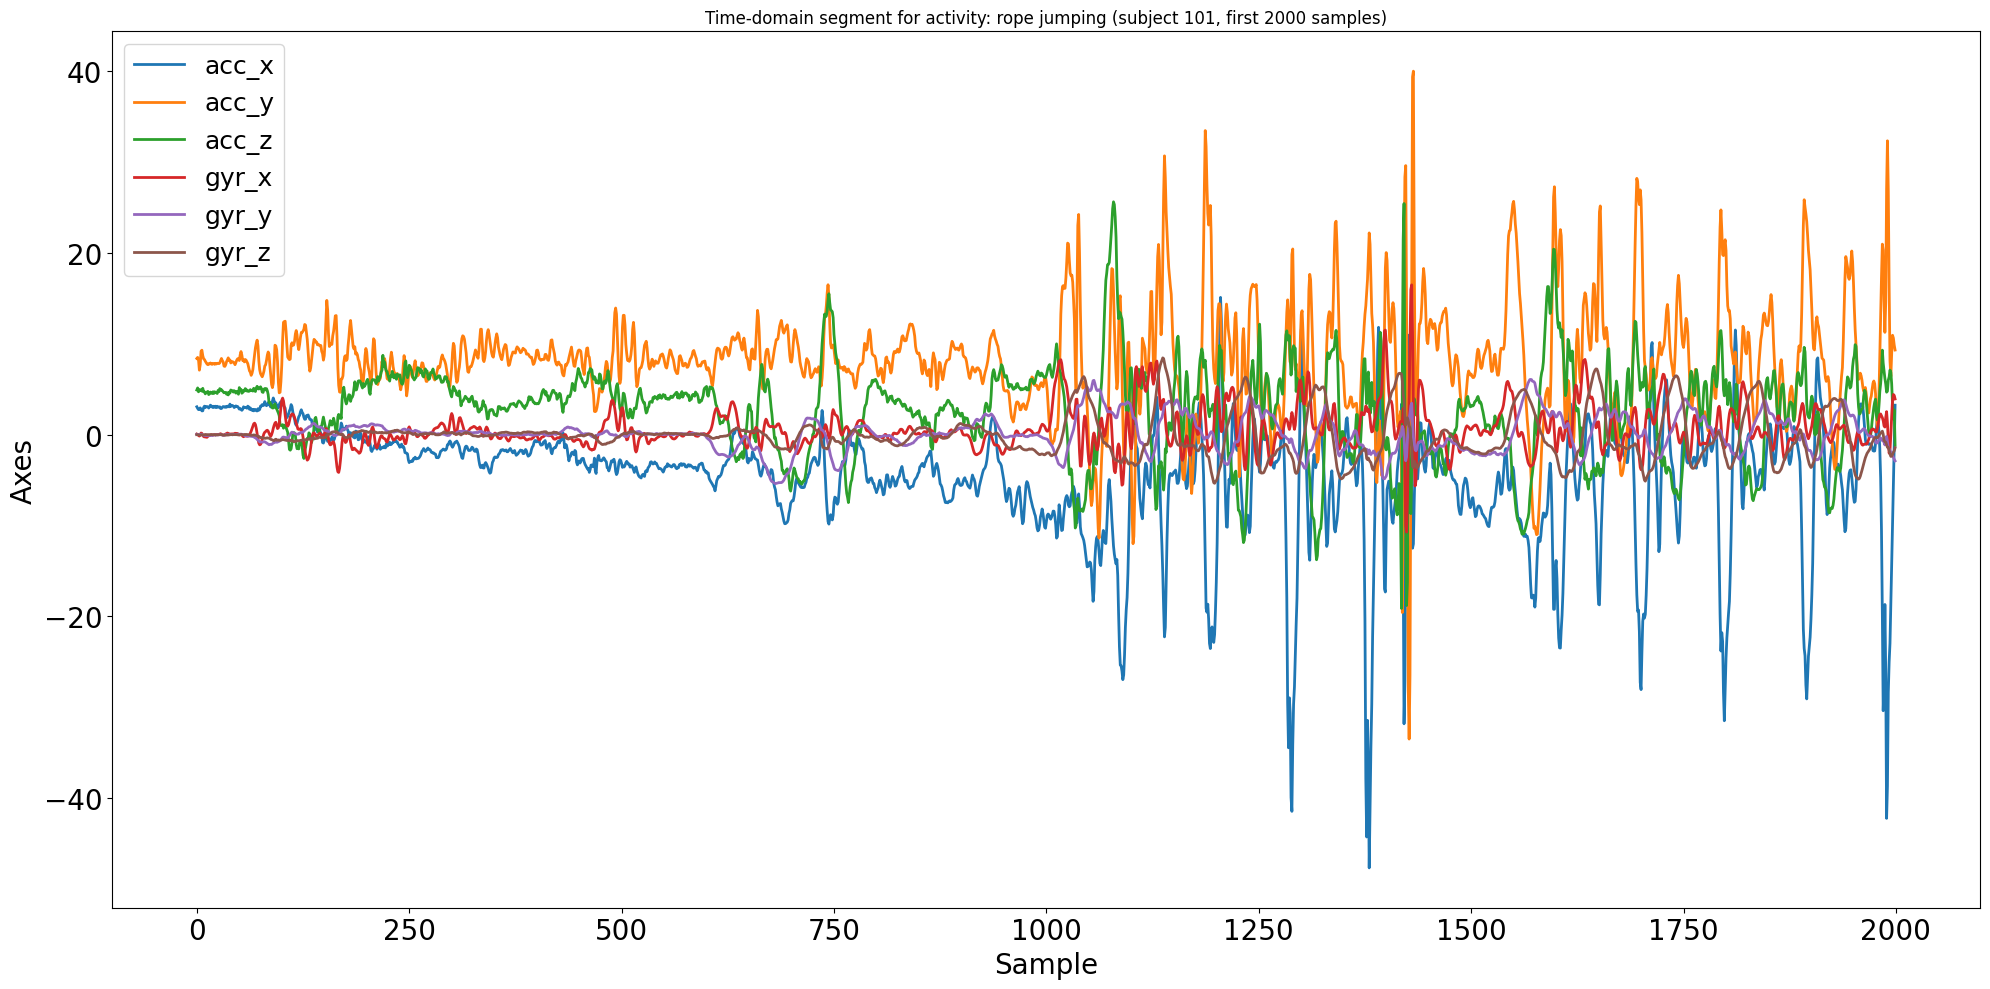

In [45]:
# Time-domain plot of one segment per activity (first samples only for readability)
activity_examples = {}
for doc in documents:
    label = doc["activity_label"]
    if label not in activity_examples:
        activity_examples[label] = doc
    if len(activity_examples) == segments_df["activity_label"].nunique():
        break

plot_samples = 2000
for activity_label, doc in activity_examples.items():
    plt.figure(figsize=(16, 6))
    plot_instance_time_domain(pd.DataFrame(doc["data"]).head(plot_samples))
    plt.title(f"Time-domain segment for activity: {activity_label} (subject {doc['subject']}, first {plot_samples} samples)")
    plt.tight_layout()
    safe_label = activity_label.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(RESULTS_DIR / f"time_domain_{safe_label}_protocol_hand_accgyr.png", bbox_inches="tight")
    plt.show()
    plt.close()

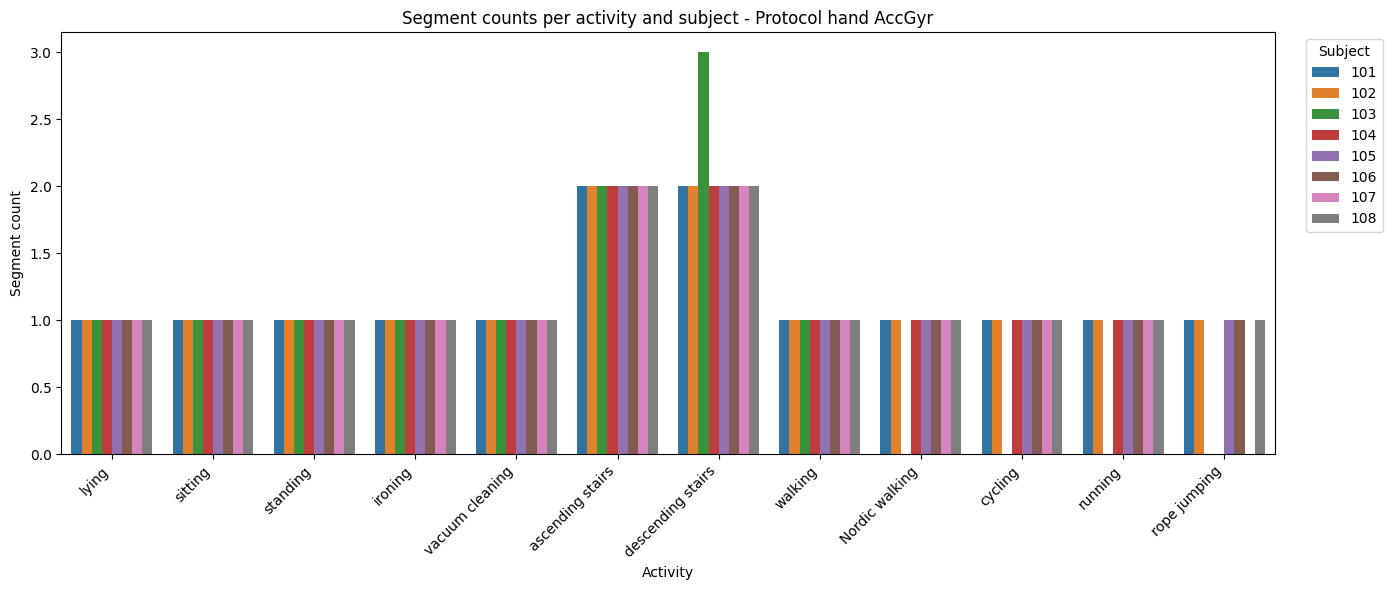

In [46]:
# Segment counts per activity and subject
plt.figure(figsize=(14, 6))
sns.countplot(data=segments_df, x="activity_label", hue="subject", palette="tab10")
plt.xticks(rotation=45, ha="right")
plt.title("Segment counts per activity and subject - Protocol hand AccGyr")
plt.ylabel("Segment count")
plt.xlabel("Activity")
plt.legend(title="Subject", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "segment_counts_protocol_hand_accgyr.png", bbox_inches="tight")
plt.show()

## Data Processing

* Apply the sliding window algorithm to each segment (use `sliding_window_pd` from `utils.py` with the parameters defined in `config.yml`).
* Apply a low-pass Butterworth filter to each window (use `apply_filter` / `filter_instances` from `utils.py`).
* Detect outliers and confirm that no `NaN` values survive from the ingestion step.

Keep `(window, activity_label, subject)` triplets together throughout this section — you need the subject ID for the train/test split.

In [47]:
# Create sliding windows for each contiguous segment.
window_size = config["sliding_window"]["ws"]
overlap_ratio = config["sliding_window"]["overlap"]
step = int(window_size * (1 - overlap_ratio))
if step <= 0:
    step = window_size
print(f"Window size: {window_size}; step size: {step}; overlap ratio: {overlap_ratio}")

windowed_instances = []
for doc in tqdm_notebook(documents, desc="Creating sliding windows"):
    df_segment = pd.DataFrame(doc["data"])
    windows = sliding_window_pd(
        df_segment,
        ws=window_size,
        overlap=step,
        w_type=config["sliding_window"]["w_type"],
        w_center=config["sliding_window"]["w_center"],
        print_stats=False,
    )
    for window in windows:
        windowed_instances.append({
            "window": window,
            "activity_label": doc["activity_label"],
            "activity_id": doc["activity_id"],
            "subject": doc["subject"],
        })

print(f"Created {len(windowed_instances)} windows from {len(documents)} segments.")

Window size: 128; step size: 64; overlap ratio: 0.5


Creating sliding windows:   0%|          | 0/107 [00:00<?, ?it/s]

Created 30101 windows from 107 segments.


In [48]:
# Apply filtering to each window and store the filtered windows in a new list
filtered_windows = filter_instances(
    [item["window"] for item in windowed_instances],
    order=config["filter"]["order"],
    wn=config["filter"]["wn"],
    filter_type=config["filter"]["type"],
)

# Combine filtered windows with their corresponding labels and subjects into a new list of instances
filtered_instances = [
    {
        "window": filtered_windows[i],
        "activity_label": windowed_instances[i]["activity_label"],
        "activity_id": windowed_instances[i]["activity_id"],
        "subject": windowed_instances[i]["subject"],
    }
    for i in range(len(filtered_windows))
]
print(f"Filtered {len(filtered_instances)} windows.")

Number of filtered instances in the list: 30101
Filtered 30101 windows.


NaN values per filtered window (sample): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
(30101, 4)


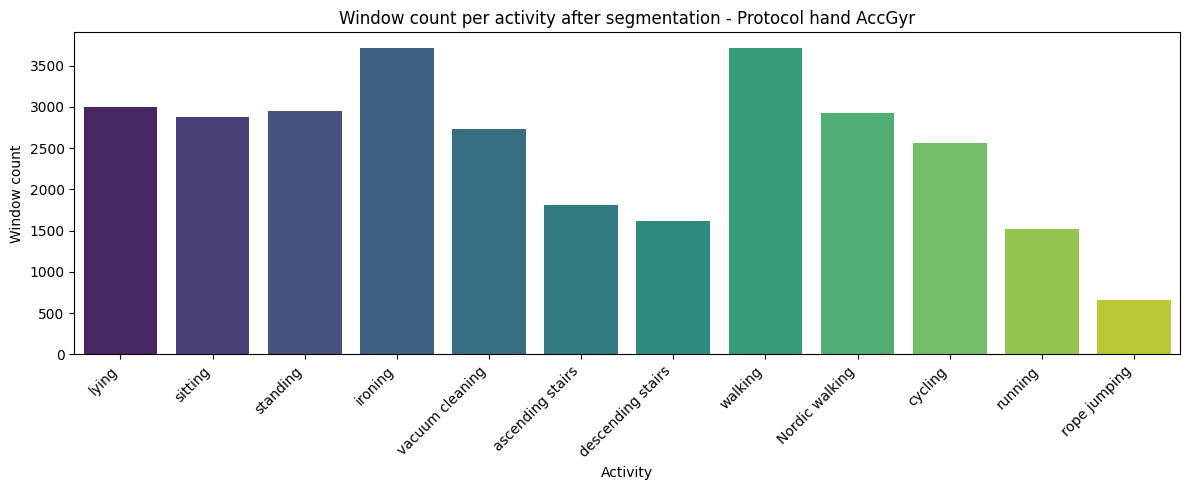

In [49]:
# Check for NaN values in the filtered windows
nan_after_filter = [inst["window"].isna().sum().sum() for inst in filtered_instances]
print("NaN values per filtered window (sample):", nan_after_filter[:10])
assert not any(nan_after_filter), "There are NaN values after filtering!"

processed_instances = pd.DataFrame([
    {
        "activity_label": inst["activity_label"],
        "activity_id": inst["activity_id"],
        "subject": inst["subject"],
        "window": inst["window"],
    }
    for inst in filtered_instances
])
print(processed_instances.shape)

plt.figure(figsize=(12, 5))
sns.countplot(data=processed_instances, x="activity_label", hue="activity_label", palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Window count per activity after segmentation - Protocol hand AccGyr")
plt.ylabel("Window count")
plt.xlabel("Activity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "window_counts_protocol_hand_accgyr.png", bbox_inches="tight")
plt.show()

## Feature Engineering

This section builds the engineered-feature dataset required by the assignment. Each filtered window is summarized with time-domain and frequency-domain features, then the same subject-disjoint train/test split is reused to compare:

* raw flattened windows
* all engineered features
* selected engineered features

In [50]:
# Feature engineering helpers.
def compute_magnitude(df):
    df = df.copy()
    prefixes = [""]
    prefixes.extend(sorted({col.rsplit("acc_x", 1)[0] for col in df.columns if col.endswith("acc_x")}))
    prefixes.extend(sorted({col.rsplit("gyr_x", 1)[0] for col in df.columns if col.endswith("gyr_x")}))
    prefixes = sorted(set(prefixes), key=lambda value: (len(value), value))

    for prefix in prefixes:
        acc_cols = [f"{prefix}acc_x", f"{prefix}acc_y", f"{prefix}acc_z"]
        gyr_cols = [f"{prefix}gyr_x", f"{prefix}gyr_y", f"{prefix}gyr_z"]
        if all(col in df.columns for col in acc_cols):
            df[f"{prefix}acc_magnitude"] = np.sqrt(np.sum(df[acc_cols] ** 2, axis=1))
        if all(col in df.columns for col in gyr_cols):
            df[f"{prefix}gyr_magnitude"] = np.sqrt(np.sum(df[gyr_cols] ** 2, axis=1))
    return df


def zero_crossing_rate(series):
    values = series.to_numpy()
    return np.mean(values[1:] * values[:-1] < 0)


def extract_time_features(df):
    features = {}
    for col in df.columns:
        s = df[col]
        features[f"{col}_mean"] = s.mean()
        features[f"{col}_median"] = s.median()
        features[f"{col}_std"] = s.std()
        features[f"{col}_min"] = s.min()
        features[f"{col}_max"] = s.max()
        features[f"{col}_iqr"] = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_energy"] = np.mean(np.square(s))
        features[f"{col}_skew"] = s.skew()
        features[f"{col}_kurtosis"] = s.kurtosis()
        features[f"{col}_zcr"] = zero_crossing_rate(s)
    return pd.Series(features)


def extract_frequency_features(df, sr=100):
    freq_features = {}
    for col in df.columns:
        values = df[col].to_numpy()
        fft_vals = np.fft.rfft(values)
        fft_freqs = np.fft.rfftfreq(len(values), d=1 / sr)
        fft_magnitude = np.abs(fft_vals)
        magnitude_sum = fft_magnitude.sum()

        if magnitude_sum > 0:
            centroid = np.sum(fft_freqs * fft_magnitude) / magnitude_sum
            bandwidth = np.sqrt(np.sum(((fft_freqs - centroid) ** 2) * fft_magnitude) / magnitude_sum)
            cumulative_energy = np.cumsum(fft_magnitude)
            rolloff_freq = fft_freqs[np.searchsorted(cumulative_energy, 0.85 * cumulative_energy[-1])]
            dominant_freq = fft_freqs[np.argmax(fft_magnitude[1:]) + 1] if len(fft_magnitude) > 1 else 0
        else:
            centroid = bandwidth = rolloff_freq = dominant_freq = 0

        freq_features[f"{col}_spectral_centroid"] = centroid
        freq_features[f"{col}_spectral_bandwidth"] = bandwidth
        freq_features[f"{col}_spectral_rolloff"] = rolloff_freq
        freq_features[f"{col}_dominant_freq"] = dominant_freq
    return pd.Series(freq_features)


def extract_window_features(window, sr=100):
    window_with_mag = compute_magnitude(window)
    return pd.concat([
        extract_time_features(window_with_mag),
        extract_frequency_features(window_with_mag, sr=sr),
    ])

# Add magnitudes to the raw-window representation too, so raw and engineered pipelines use the same channels.
processed_instances["window"] = processed_instances["window"].apply(compute_magnitude)

feature_rows = []
for _, inst in tqdm_notebook(processed_instances.iterrows(), total=len(processed_instances), desc="Extracting engineered features"):
    features = extract_window_features(inst["window"], sr=100)
    features["activity_id"] = inst["activity_id"]
    features["activity_label"] = inst["activity_label"]
    features["subject"] = inst["subject"]
    feature_rows.append(features)

feature_df = pd.DataFrame(feature_rows).replace([np.inf, -np.inf], np.nan).dropna()
print("Engineered feature table shape:", feature_df.shape)
feature_df.head()

Extracting engineered features:   0%|          | 0/30101 [00:00<?, ?it/s]

Engineered feature table shape: (30101, 115)


,acc_x_mean,acc_x_median,acc_x_std,acc_x_min,acc_x_max,acc_x_iqr,acc_x_energy,acc_x_skew,acc_x_kurtosis,acc_x_zcr,...,acc_magnitude_spectral_bandwidth,acc_magnitude_spectral_rolloff,acc_magnitude_dominant_freq,gyr_magnitude_spectral_centroid,gyr_magnitude_spectral_bandwidth,gyr_magnitude_spectral_rolloff,gyr_magnitude_dominant_freq,activity_id,activity_label,subject
0,1.952403,2.292246,1.008618,-0.718507,2.917144,0.467098,4.821240,-1.698010,1.490977,0.007874,...,3.574360,0.00000,7.03125,5.949805,10.515673,12.5000,0.78125,1.0,lying,101
1,-0.140620,-0.764495,1.937197,-2.725531,2.920927,3.821099,3.743188,0.377259,-1.449643,0.007874,...,5.361850,3.12500,5.46875,3.020686,5.948227,7.8125,0.78125,1.0,lying,101
2,-1.478351,-1.473888,0.628381,-2.725160,0.164779,0.748373,2.577300,0.157067,-0.011828,0.015748,...,4.125079,2.34375,4.68750,4.287882,8.544337,9.3750,0.78125,1.0,lying,101
3,-1.631303,-1.466645,0.796467,-3.012249,0.163102,1.004502,3.290552,-0.290896,-0.499879,0.015748,...,7.527650,3.90625,0.78125,3.553919,6.904962,6.2500,2.34375,1.0,lying,101
4,-1.716210,-1.575664,0.830681,-3.040593,-0.083469,1.518426,3.630016,-0.009280,-1.161586,0.000000,...,4.659261,3.12500,1.56250,4.580489,7.796182,9.3750,0.78125,1.0,lying,101


## Train/Test split

The split must be **by subject**: 6–7 subjects in train, 2–3 in test, with **no overlap**. This forces the model to generalize to users it has never seen, which is the realistic deployment scenario.

Do **not** use `train_test_split` with random shuffling — that would leak windows from the same subject into both sets and inflate the reported metrics.

In [51]:
# Train-test split by subject 

X_train, y_train = [], []
X_test, y_test = [], []


In [52]:
# Define train and test subjects based on the Protocol split
TRAIN_SUBJECTS = ["101", "102", "103", "104", "105", "106", "107"]
TEST_SUBJECTS  = ["108", "109"]

assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)

train_labels = set(processed_instances.loc[processed_instances["subject"].isin(TRAIN_SUBJECTS), "activity_id"])
test_labels = set(processed_instances.loc[processed_instances["subject"].isin(TEST_SUBJECTS), "activity_id"])
print("Train labels:", sorted(train_labels))
print("Test labels:", sorted(test_labels))
print("Labels missing from train:", sorted(test_labels - train_labels))
print("Labels missing from test:", sorted(train_labels - test_labels))

Train labels: [1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]
Test labels: [1, 2, 3, 4, 5, 6, 7, 12, 13, 16, 17, 24]
Labels missing from train: []
Labels missing from test: []


In [53]:
# Raw/windowed time-series representation: flatten each filtered window.
X_train_raw, y_train_raw = [], []
X_test_raw, y_test_raw = [], []

for _, inst in processed_instances.iterrows():
    subject = inst["subject"]
    features = inst["window"].to_numpy().flatten()
    label = inst["activity_id"]

    if subject in TRAIN_SUBJECTS:
        X_train_raw.append(features)
        y_train_raw.append(label)
    elif subject in TEST_SUBJECTS:
        X_test_raw.append(features)
        y_test_raw.append(label)

X_train_raw = np.vstack(X_train_raw)
X_test_raw = np.vstack(X_test_raw)
y_train_raw = np.array(y_train_raw)
y_test_raw = np.array(y_test_raw)

# Keep the old variable names for the raw/PCA baseline cells below.
X_train, X_test = X_train_raw, X_test_raw
y_train, y_test = y_train_raw, y_test_raw

print("Raw train shape:", X_train_raw.shape)
print("Raw test shape:", X_test_raw.shape)

Raw train shape: (26025, 1024)
Raw test shape: (4076, 1024)


## Scaling

Fit the scaler on the training subjects only, then apply it to the test subjects.

In [54]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [55]:
# Scaling the features using StandardScaler (zero mean, unit variance)
scaler = StandardScaler()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Fit the scaler on the training data and transform both training and test data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Scaled feature shape: {X_train.shape}")

X_train shape: (26025, 1024)
X_test shape: (4076, 1024)
Scaled feature shape: (26025, 1024)


## Dimensionality Reduction (PCA)

Apply PCA to reduce the feature dimensionality while retaining most of the variance. This is especially useful for high-dimensional windowed sensor data.



In [56]:
from sklearn.decomposition import PCA

# Apply PCA with 95% variance retention (or adjust n_components based on your analysis)
n_components = config["PCA"]["n_comp"]  

print(f"\nApplying PCA with {n_components} components (95% variance retention)...")

pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data only (avoid data leakage)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"PCA-reduced feature shape: {X_train_pca.shape}")
print(f"Dimensionality reduction: {X_train.shape[1]} → {X_train_pca.shape[1]} features ({100*X_train_pca.shape[1]/X_train.shape[1]:.1f}%)")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.4f}")



Applying PCA with 0.95 components (95% variance retention)...
PCA-reduced feature shape: (26025, 72)
Dimensionality reduction: 1024 → 72 features (7.0%)
Variance retained: 0.9504


Original feature dimension: 1024
Components to retain 85% variance: 35
Components to retain 95% variance: 72
Variance retained with 72 components: 0.9504


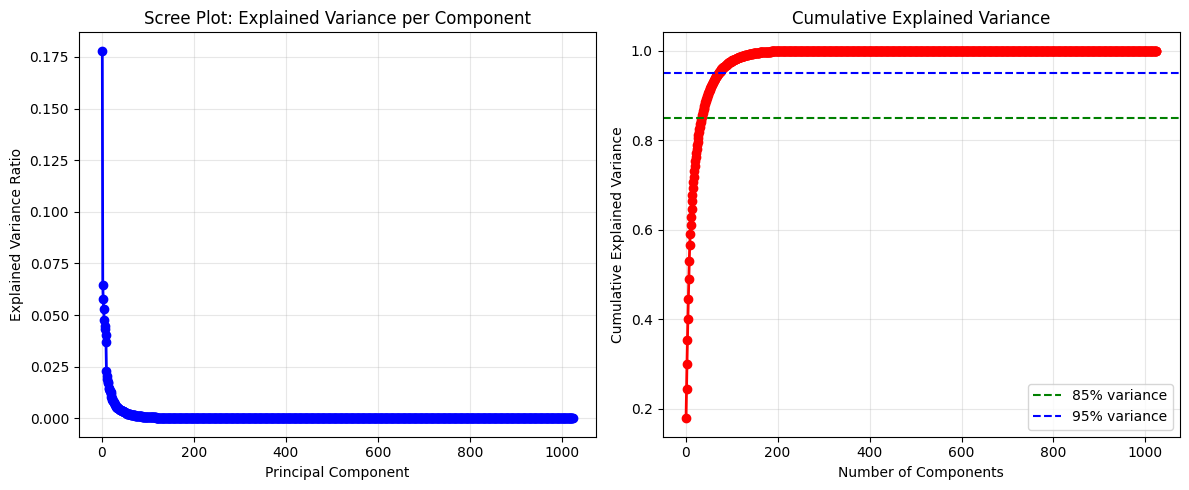

In [57]:
from sklearn.decomposition import PCA

# Analyze explained variance with all components
pca_full = PCA()
pca_full.fit(X_train)

# Cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Plot explained variance
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'bo-', linewidth=2)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot: Explained Variance per Component")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-', linewidth=2)
plt.axhline(y=0.85, color='g', linestyle='--', label='85% variance')
plt.axhline(y=0.95, color='b', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Determine optimal number of components to retain 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_85 = np.argmax(cumsum_var >= 0.85) + 1

print(f"Original feature dimension: {X_train.shape[1]}")
print(f"Components to retain 85% variance: {n_components_85}")
print(f"Components to retain 95% variance: {n_components_95}")
print(f"Variance retained with {n_components_95} components: {cumsum_var[n_components_95-1]:.4f}")


### Apply simple classifier

In [58]:
# Use PCA-reduced features
print(f"Using PCA-Reduced Features: {X_train_pca.shape[1]} features")

Using PCA-Reduced Features: 72 features


In [59]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [60]:
# Train classifiers on PCA-reduced features

# Hyperparameters from config for SVC
kernel = config["classifier"]["SVC"]["kernel"]
C = config["classifier"]["SVC"]["C"]
gamma = config["classifier"]["SVC"]["gamma"]
class_weight = config["classifier"]["SVC"].get("class_weight", None)

# Hyperparameters from config for Random Forest
n_estimators = config["classifier"]["RandomForest"]["n_estimators"]
max_depth = config["classifier"]["RandomForest"]["max_depth"]

print("Training on PCA-Reduced Features...")

# SVM classifier
print("Training SVC:")
svm = SVC(kernel=kernel, C=C, gamma=gamma, class_weight=class_weight, random_state=42)
svm.fit(X_train_pca, y_train)

# Random Forest classifier
print("Training Random Forest:")
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
rf.fit(X_train_pca, y_train)


Training on PCA-Reduced Features...
Training SVC:
Training Random Forest:


RandomForestClassifier(max_depth=10, random_state=42)

### Evaluate simple classifier


EVALUATION: Raw Windowed PCA Models

Raw PCA SVC
  Accuracy:  0.4119
  Precision: 0.4811
  Recall:    0.4119
  F1-Score:  0.3698
              precision    recall  f1-score   support

           1       0.81      0.94      0.87       376
           2       0.37      0.50      0.43       357
           3       0.75      0.22      0.35       392
           4       0.60      0.06      0.11       491
           5       0.70      0.89      0.78       257
           6       0.76      0.76      0.76       397
           7       0.00      0.00      0.00       450
          12       0.26      0.37      0.30       180
          13       0.20      0.55      0.29       148
          16       0.19      0.70      0.30       378
          17       0.47      0.16      0.23       514
          24       0.50      0.01      0.01       136

    accuracy                           0.41      4076
   macro avg       0.47      0.43      0.37      4076
weighted avg       0.48      0.41      0.37      4076



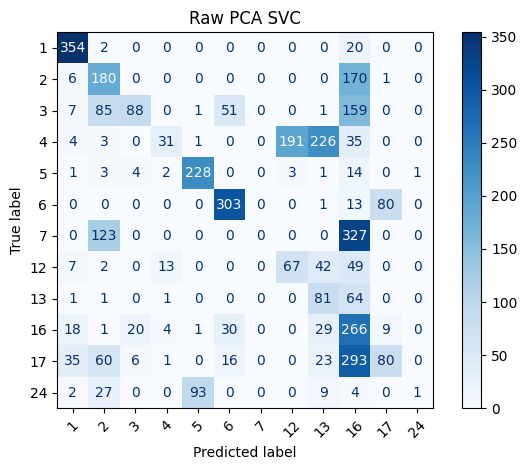


Raw PCA Random Forest
  Accuracy:  0.4374
  Precision: 0.4888
  Recall:    0.4374
  F1-Score:  0.3774
              precision    recall  f1-score   support

           1       0.96      0.93      0.95       376
           2       0.38      0.50      0.43       357
           3       0.84      0.22      0.35       392
           4       0.55      0.92      0.69       491
           5       0.89      0.12      0.22       257
           6       0.31      0.89      0.47       397
           7       0.00      0.00      0.00       450
          12       0.28      0.20      0.23       180
          13       0.23      0.11      0.15       148
          16       0.26      0.53      0.34       378
          17       0.43      0.14      0.21       514
          24       1.00      0.02      0.04       136

    accuracy                           0.44      4076
   macro avg       0.51      0.38      0.34      4076
weighted avg       0.49      0.44      0.38      4076



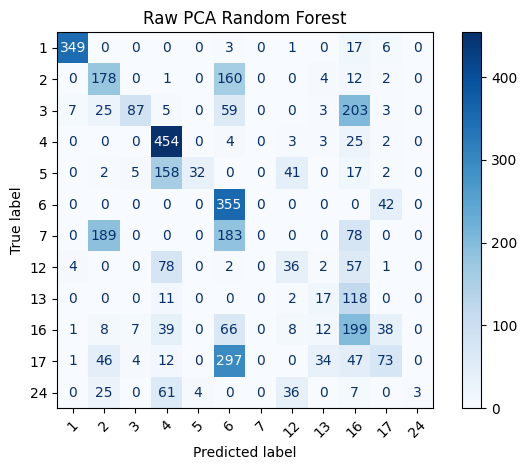


SUMMARY TABLE
             Approach  Accuracy  Precision   Recall  F1-Score
          Raw PCA SVC  0.411923   0.481058 0.411923  0.369795
Raw PCA Random Forest  0.437439   0.488822 0.437439  0.377369


In [61]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

summary_results = []

def evaluate_model(name, model, X_test_eval, y_test_eval, result_rows, labels=None, save_cm=None):
    y_pred = model.predict(X_test_eval)
    acc = accuracy_score(y_test_eval, y_pred)
    precision = precision_score(y_test_eval, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test_eval, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test_eval, y_pred, average="weighted", zero_division=0)

    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(classification_report(y_test_eval, y_pred, zero_division=0))

    result_rows.append({
        "Approach": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    })

    if save_cm is not None:
        disp = ConfusionMatrixDisplay.from_predictions(y_test_eval, y_pred, display_labels=labels, xticks_rotation=45, cmap="Blues")
        disp.ax_.set_title(name)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / save_cm, bbox_inches="tight")
        plt.show()

    return y_pred

print("\nEVALUATION: Raw Windowed PCA Models")
print("=" * 60)
raw_label_order = sorted(np.unique(np.concatenate([y_train, y_test])))

evaluate_model("Raw PCA SVC", svm, X_test_pca, y_test, summary_results, labels=raw_label_order, save_cm="cm_raw_pca_svc.png")
evaluate_model("Raw PCA Random Forest", rf, X_test_pca, y_test, summary_results, labels=raw_label_order, save_cm="cm_raw_pca_random_forest.png")

results_df = pd.DataFrame(summary_results)
print("\nSUMMARY TABLE")
print(results_df.to_string(index=False))

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [63]:
from sklearn.metrics import classification_report

## Engineered-Feature Modeling

Train and evaluate models on the extracted feature table. This satisfies the full-feature comparison required by the assignment.

All engineered features train shape: (26025, 112)
All engineered features test shape: (4076, 112)

All Engineered Features SVC
  Accuracy:  0.5469
  Precision: 0.5489
  Recall:    0.5469
  F1-Score:  0.4865
              precision    recall  f1-score   support

         1.0       0.70      0.93      0.80       376
         2.0       0.38      0.79      0.52       357
         3.0       0.43      0.75      0.55       392
         4.0       0.89      0.81      0.85       491
         5.0       0.67      0.02      0.03       257
         6.0       0.89      0.93      0.91       397
         7.0       0.00      0.00      0.00       450
        12.0       0.62      0.63      0.62       180
        13.0       0.43      0.76      0.55       148
        16.0       0.28      0.54      0.37       378
        17.0       0.82      0.19      0.31       514
        24.0       0.00      0.00      0.00       136

    accuracy                           0.55      4076
   macro avg       0.51      0.53  

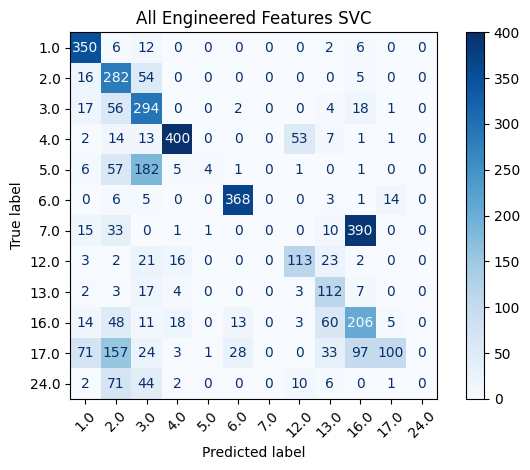


All Engineered Features Random Forest
  Accuracy:  0.7348
  Precision: 0.8120
  Recall:    0.7348
  F1-Score:  0.7472
              precision    recall  f1-score   support

         1.0       0.98      0.91      0.94       376
         2.0       0.82      0.87      0.84       357
         3.0       0.76      0.79      0.78       392
         4.0       0.89      0.90      0.90       491
         5.0       0.99      0.89      0.94       257
         6.0       0.91      0.85      0.88       397
         7.0       0.94      0.31      0.46       450
        12.0       0.62      0.62      0.62       180
        13.0       0.18      0.71      0.29       148
        16.0       0.63      0.47      0.54       378
        17.0       0.71      0.78      0.74       514
        24.0       1.00      0.65      0.79       136

    accuracy                           0.73      4076
   macro avg       0.79      0.73      0.73      4076
weighted avg       0.81      0.73      0.75      4076



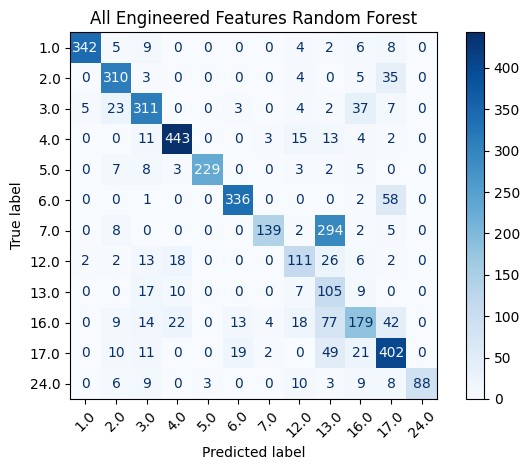

array([ 3.,  3., 12., ...,  2., 17., 17.])

In [64]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

metadata_cols = ["activity_id", "activity_label", "subject"]
feature_cols = [col for col in feature_df.columns if col not in metadata_cols]

train_mask = feature_df["subject"].isin(TRAIN_SUBJECTS)
test_mask = feature_df["subject"].isin(TEST_SUBJECTS)

X_train_features = feature_df.loc[train_mask, feature_cols]
X_test_features = feature_df.loc[test_mask, feature_cols]
y_train_features = feature_df.loc[train_mask, "activity_id"].to_numpy()
y_test_features = feature_df.loc[test_mask, "activity_id"].to_numpy()

feature_scaler = StandardScaler()
X_train_features_scaled = feature_scaler.fit_transform(X_train_features)
X_test_features_scaled = feature_scaler.transform(X_test_features)

print("All engineered features train shape:", X_train_features_scaled.shape)
print("All engineered features test shape:", X_test_features_scaled.shape)

svc_features = SVC(kernel=kernel, C=C, gamma=gamma, class_weight="balanced", random_state=42)
rf_features = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight="balanced_subsample", random_state=42)

svc_features.fit(X_train_features_scaled, y_train_features)
rf_features.fit(X_train_features_scaled, y_train_features)

feature_label_order = sorted(np.unique(np.concatenate([y_train_features, y_test_features])))
evaluate_model("All Engineered Features SVC", svc_features, X_test_features_scaled, y_test_features, summary_results, labels=feature_label_order, save_cm="cm_all_features_svc.png")
evaluate_model("All Engineered Features Random Forest", rf_features, X_test_features_scaled, y_test_features, summary_results, labels=feature_label_order, save_cm="cm_all_features_random_forest.png")

## Feature Selection

Select a smaller subset of the engineered features with mutual information, then train/evaluate the same models again.

Selected 65 features:
- acc_x_mean
- acc_x_median
- acc_x_std
- acc_x_min
- acc_x_max
- acc_x_iqr
- acc_x_energy
- acc_y_mean
- acc_y_median
- acc_y_std
- acc_y_min
- acc_y_max
- acc_y_iqr
- acc_y_energy
- acc_z_mean
- acc_z_median
- acc_z_std
- acc_z_min
- acc_z_max
- acc_z_iqr
- acc_z_energy
- gyr_x_mean
- gyr_x_median
- gyr_x_std
- gyr_x_min
- gyr_x_max
- gyr_x_iqr
- gyr_x_energy
- gyr_y_median
- gyr_y_std
- gyr_y_min
- gyr_y_max
- gyr_y_iqr
- gyr_y_energy
- gyr_z_mean
- gyr_z_median
- gyr_z_std
- gyr_z_min
- gyr_z_max
- gyr_z_iqr
- gyr_z_energy
- acc_magnitude_mean
- acc_magnitude_median
- acc_magnitude_std
- acc_magnitude_min
- acc_magnitude_max
- acc_magnitude_iqr
- acc_magnitude_energy
- gyr_magnitude_mean
- gyr_magnitude_median
- gyr_magnitude_std
- gyr_magnitude_min
- gyr_magnitude_max
- gyr_magnitude_iqr
- gyr_magnitude_energy
- acc_x_spectral_centroid
- acc_x_spectral_rolloff
- acc_y_spectral_centroid
- acc_y_spectral_rolloff
- acc_z_spectral_centroid
- acc_z_spectral_rollof

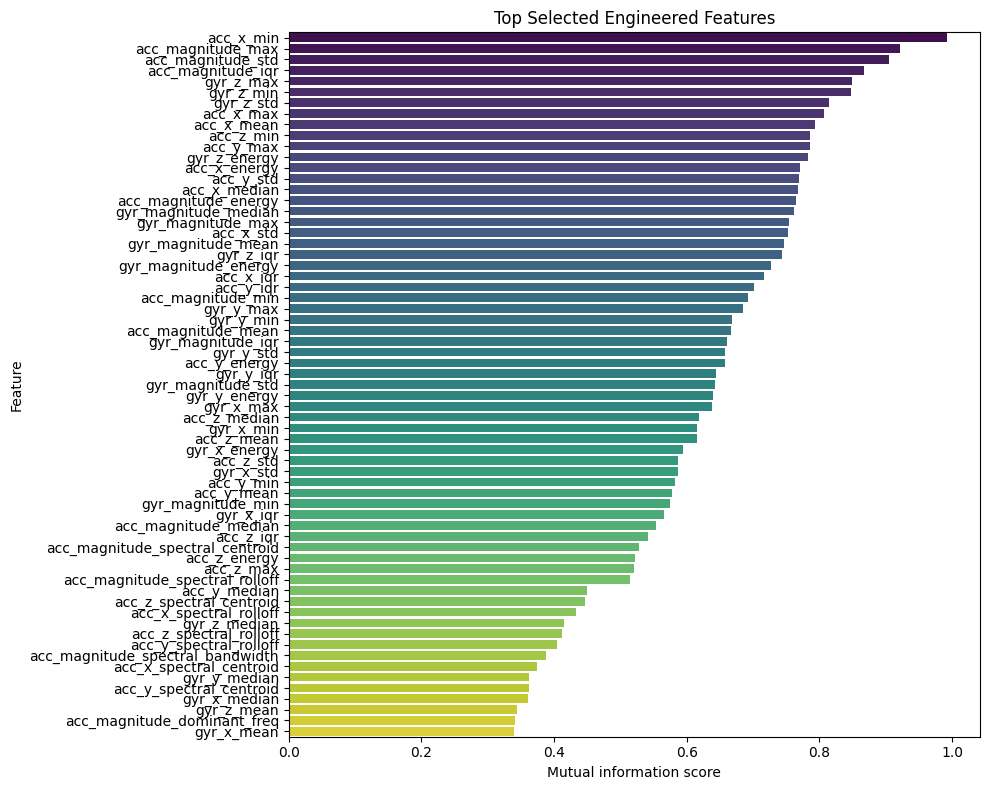


Selected Engineered Features SVC
  Accuracy:  0.5650
  Precision: 0.5849
  Recall:    0.5650
  F1-Score:  0.5252
              precision    recall  f1-score   support

         1.0       0.57      0.93      0.71       376
         2.0       0.33      0.78      0.46       357
         3.0       0.87      0.36      0.51       392
         4.0       0.89      0.74      0.81       491
         5.0       0.77      0.89      0.83       257
         6.0       0.93      0.93      0.93       397
         7.0       0.00      0.00      0.00       450
        12.0       0.52      0.62      0.57       180
        13.0       0.54      0.77      0.64       148
        16.0       0.29      0.61      0.39       378
        17.0       0.82      0.24      0.37       514
        24.0       0.00      0.00      0.00       136

    accuracy                           0.57      4076
   macro avg       0.54      0.57      0.52      4076
weighted avg       0.58      0.57      0.53      4076



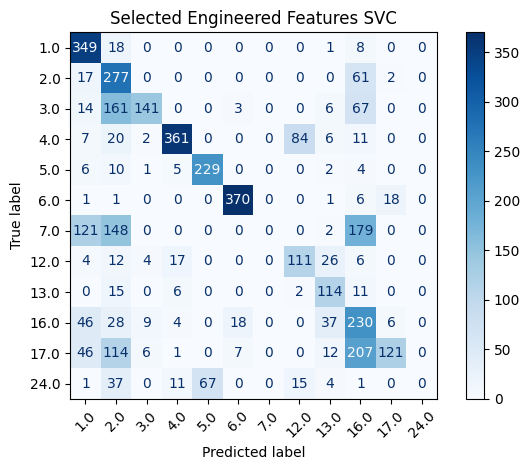


Selected Engineered Features Random Forest
  Accuracy:  0.7441
  Precision: 0.8153
  Recall:    0.7441
  F1-Score:  0.7565
              precision    recall  f1-score   support

         1.0       0.96      0.91      0.93       376
         2.0       0.83      0.88      0.85       357
         3.0       0.83      0.79      0.81       392
         4.0       0.92      0.87      0.89       491
         5.0       0.98      0.89      0.93       257
         6.0       0.87      0.91      0.89       397
         7.0       0.97      0.42      0.58       450
        12.0       0.46      0.73      0.56       180
        13.0       0.22      0.72      0.34       148
        16.0       0.57      0.48      0.52       378
        17.0       0.76      0.75      0.75       514
        24.0       1.00      0.43      0.60       136

    accuracy                           0.74      4076
   macro avg       0.78      0.73      0.72      4076
weighted avg       0.82      0.74      0.76      4076



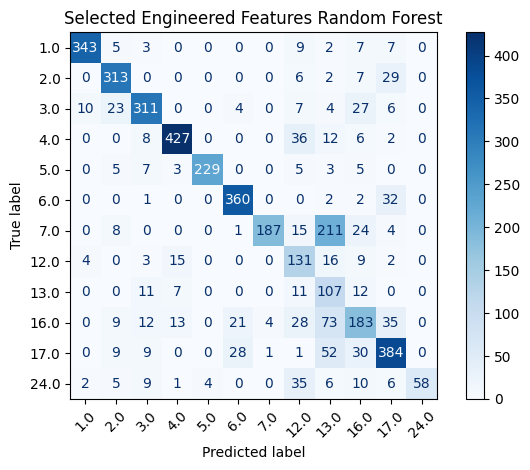


FINAL COMPARISON
                                  Approach  Accuracy  Precision   Recall  F1-Score
Selected Engineered Features Random Forest  0.744112   0.815278 0.744112  0.756516
     All Engineered Features Random Forest  0.734789   0.811960 0.734789  0.747188
          Selected Engineered Features SVC  0.565015   0.584852 0.565015  0.525220
               All Engineered Features SVC  0.546860   0.548850 0.546860  0.486511
                     Raw PCA Random Forest  0.437439   0.488822 0.437439  0.377369
                               Raw PCA SVC  0.411923   0.481058 0.411923  0.369795


In [65]:
k_features = min(65, X_train_features_scaled.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_train_selected = selector.fit_transform(X_train_features_scaled, y_train_features)
X_test_selected = selector.transform(X_test_features_scaled)
selected_features = X_train_features.columns[selector.get_support()].tolist()

print(f"Selected {len(selected_features)} features:")
for feature in selected_features:
    print("-", feature)

scores = pd.DataFrame({
    "feature": X_train_features.columns,
    "score": selector.scores_,
}).sort_values("score", ascending=False).head(k_features)

plt.figure(figsize=(10, 8))
sns.barplot(data=scores, y="feature", x="score", hue="feature", palette="viridis", legend=False)
plt.title("Top Selected Engineered Features")
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "selected_feature_scores.png", bbox_inches="tight")
plt.show()

svc_selected = SVC(kernel=kernel, C=C, gamma=gamma, class_weight="balanced", random_state=42)
rf_selected = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight="balanced_subsample", random_state=42)

svc_selected.fit(X_train_selected, y_train_features)
rf_selected.fit(X_train_selected, y_train_features)

evaluate_model("Selected Engineered Features SVC", svc_selected, X_test_selected, y_test_features, summary_results, labels=feature_label_order, save_cm="cm_selected_features_svc.png")
evaluate_model("Selected Engineered Features Random Forest", rf_selected, X_test_selected, y_test_features, summary_results, labels=feature_label_order, save_cm="cm_selected_features_random_forest.png")

final_results_df = pd.DataFrame(summary_results).sort_values("F1-Score", ascending=False)
print("\nFINAL COMPARISON")
print(final_results_df.to_string(index=False))
final_results_df.to_csv(RESULTS_DIR / "model_comparison_protocol_hand_accgyr.csv", index=False)

## Combined Wrist + Chest + Ankle Model

This experiment concatenates the three IMU locations into one multi-sensor window, then trains SVC and Random Forest on engineered features. It answers how performance changes when all available inertial sensors are used together.

Combined Protocol segments: 107


Windowing combined IMUs:   0%|          | 0/107 [00:00<?, ?it/s]

Number of filtered instances in the list: 30101
Combined processed windows: (30101, 4)


Features combined IMUs:   0%|          | 0/30101 [00:00<?, ?it/s]


Combined Wrist+Chest+Ankle Engineered Features SVC
  Accuracy:  0.7034
  Precision: 0.6823
  Recall:    0.7034
  F1-Score:  0.6630
              precision    recall  f1-score   support

         1.0       0.87      0.96      0.91       376
         2.0       0.74      0.73      0.74       357
         3.0       0.49      0.89      0.63       392
         4.0       0.68      0.93      0.79       491
         5.0       0.90      0.88      0.89       257
         6.0       0.95      0.93      0.94       397
         7.0       0.00      0.00      0.00       450
        12.0       0.70      0.78      0.74       180
        13.0       0.34      0.82      0.48       148
        16.0       0.72      0.86      0.79       378
        17.0       0.92      0.42      0.58       514
        24.0       1.00      0.31      0.47       136

    accuracy                           0.70      4076
   macro avg       0.69      0.71      0.66      4076
weighted avg       0.68      0.70      0.66      4076



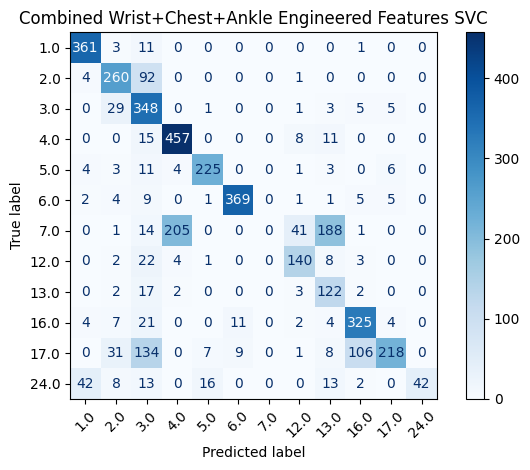


Combined Wrist+Chest+Ankle Engineered Features Random Forest
  Accuracy:  0.9036
  Precision: 0.9119
  Recall:    0.9036
  F1-Score:  0.9054
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97       376
         2.0       0.81      0.94      0.87       357
         3.0       0.72      0.88      0.79       392
         4.0       0.97      0.94      0.96       491
         5.0       1.00      0.89      0.94       257
         6.0       0.99      0.94      0.96       397
         7.0       0.99      0.94      0.96       450
        12.0       0.85      0.76      0.80       180
        13.0       0.79      0.80      0.79       148
        16.0       0.87      0.86      0.87       378
        17.0       0.89      0.93      0.91       514
        24.0       1.00      0.76      0.86       136

    accuracy                           0.90      4076
   macro avg       0.91      0.88      0.89      4076
weighted avg       0.91      0.90      0.91   

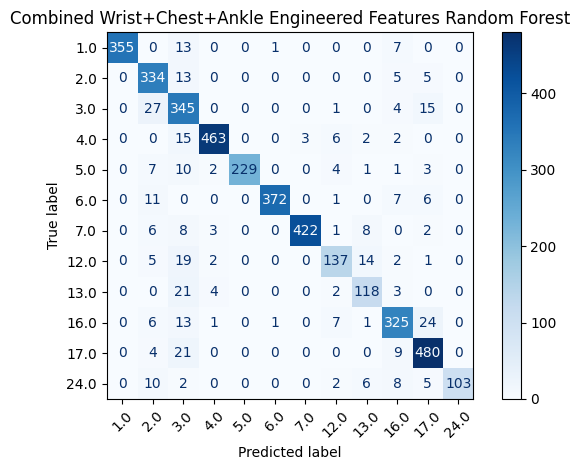


COMBINED SENSOR MODEL RESULTS
                                                    Approach  Accuracy  Precision   Recall  F1-Score
Combined Wrist+Chest+Ankle Engineered Features Random Forest  0.903582   0.911891 0.903582  0.905363
          Combined Wrist+Chest+Ankle Engineered Features SVC  0.703386   0.682284 0.703386  0.662981


In [66]:
RUN_COMBINED_SENSOR_MODEL = True


def load_combined_imu_documents():
    sensor_docs = list(coll.find({"split": "Protocol", "sensor": "AccGyr"}))
    docs_by_key = {}
    for doc in sensor_docs:
        key = (
            doc["subject"],
            doc.get("segment_index"),
            doc["activity_id"],
            doc["activity_label"],
        )
        docs_by_key.setdefault(key, {})[doc["imu_location"]] = doc

    combined_documents = []
    for (subject, segment_index, activity_id, activity_label), location_docs in docs_by_key.items():
        if not {"hand", "chest", "ankle"}.issubset(location_docs):
            continue

        min_len = min(len(location_docs[loc]["data"]["acc_x"]) for loc in ["hand", "chest", "ankle"])
        combined_data = {}
        for loc in ["hand", "chest", "ankle"]:
            for axis_name, values in location_docs[loc]["data"].items():
                combined_data[f"{loc}_{axis_name}"] = values[:min_len]

        combined_documents.append({
            "data": combined_data,
            "activity_id": activity_id,
            "activity_label": activity_label,
            "subject": subject,
            "segment_index": segment_index,
            "sr": 100,
            "segment_length": min_len,
        })

    return combined_documents


def build_combined_processed_instances(combined_documents):
    combined_windowed = []
    for doc in tqdm_notebook(combined_documents, desc="Windowing combined IMUs"):
        df_segment = pd.DataFrame(doc["data"])
        windows = sliding_window_pd(
            df_segment,
            ws=window_size,
            overlap=step,
            w_type=config["sliding_window"]["w_type"],
            w_center=config["sliding_window"]["w_center"],
            print_stats=False,
        )
        for window in windows:
            combined_windowed.append({
                "window": window,
                "activity_label": doc["activity_label"],
                "activity_id": doc["activity_id"],
                "subject": doc["subject"],
            })

    combined_filtered_windows = filter_instances(
        [item["window"] for item in combined_windowed],
        order=config["filter"]["order"],
        wn=config["filter"]["wn"],
        filter_type=config["filter"]["type"],
    )

    return pd.DataFrame([
        {
            "activity_label": combined_windowed[i]["activity_label"],
            "activity_id": combined_windowed[i]["activity_id"],
            "subject": combined_windowed[i]["subject"],
            "window": compute_magnitude(combined_filtered_windows[i]),
        }
        for i in range(len(combined_filtered_windows))
    ])


def build_feature_table_from_processed(processed_df, desc):
    rows = []
    for _, inst in tqdm_notebook(processed_df.iterrows(), total=len(processed_df), desc=desc):
        features = extract_window_features(inst["window"], sr=100)
        features["activity_id"] = inst["activity_id"]
        features["activity_label"] = inst["activity_label"]
        features["subject"] = inst["subject"]
        rows.append(features)
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()


if RUN_COMBINED_SENSOR_MODEL:
    combined_documents = load_combined_imu_documents()
    print(f"Combined Protocol segments: {len(combined_documents)}")

    combined_processed = build_combined_processed_instances(combined_documents)
    print("Combined processed windows:", combined_processed.shape)

    combined_feature_df = build_feature_table_from_processed(combined_processed, "Features combined IMUs")
    combined_feature_cols = [col for col in combined_feature_df.columns if col not in metadata_cols]

    train_mask_combined = combined_feature_df["subject"].isin(TRAIN_SUBJECTS)
    test_mask_combined = combined_feature_df["subject"].isin(TEST_SUBJECTS)

    X_train_combined = combined_feature_df.loc[train_mask_combined, combined_feature_cols]
    X_test_combined = combined_feature_df.loc[test_mask_combined, combined_feature_cols]
    y_train_combined = combined_feature_df.loc[train_mask_combined, "activity_id"].to_numpy()
    y_test_combined = combined_feature_df.loc[test_mask_combined, "activity_id"].to_numpy()

    combined_scaler = StandardScaler()
    X_train_combined_scaled = combined_scaler.fit_transform(X_train_combined)
    X_test_combined_scaled = combined_scaler.transform(X_test_combined)

    combined_svc = SVC(kernel=kernel, C=C, gamma=gamma, class_weight="balanced", random_state=42)
    combined_rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=42,
    )

    combined_svc.fit(X_train_combined_scaled, y_train_combined)
    combined_rf.fit(X_train_combined_scaled, y_train_combined)

    combined_results = []
    combined_label_order = sorted(np.unique(np.concatenate([y_train_combined, y_test_combined])))
    evaluate_model(
        "Combined Wrist+Chest+Ankle Engineered Features SVC",
        combined_svc,
        X_test_combined_scaled,
        y_test_combined,
        combined_results,
        labels=combined_label_order,
        save_cm="cm_combined_all_imus_svc.png",
    )
    evaluate_model(
        "Combined Wrist+Chest+Ankle Engineered Features Random Forest",
        combined_rf,
        X_test_combined_scaled,
        y_test_combined,
        combined_results,
        labels=combined_label_order,
        save_cm="cm_combined_all_imus_random_forest.png",
    )

    combined_results_df = pd.DataFrame(combined_results).sort_values("F1-Score", ascending=False)
    print("\nCOMBINED SENSOR MODEL RESULTS")
    print(combined_results_df.to_string(index=False))
    combined_results_df.to_csv(RESULTS_DIR / "combined_wrist_chest_ankle_model_comparison.csv", index=False)
else:
    print("Combined sensor model skipped. Set RUN_COMBINED_SENSOR_MODEL = True to run it.")

## Sensor Configuration Comparison

The wrist configuration is the baseline. In PAMAP2 this IMU is stored as `hand`. This section repeats the engineered-feature Random Forest pipeline for hand, chest, and ankle IMUs so the report can compare sensor placement trade-offs.


hand: loaded 107 Protocol segments


Windowing hand:   0%|          | 0/107 [00:00<?, ?it/s]

Number of filtered instances in the list: 30101
hand: processed windows (30101, 4)


Features hand:   0%|          | 0/30101 [00:00<?, ?it/s]


Hand All Engineered Features Random Forest
  Accuracy:  0.7348
  Precision: 0.8120
  Recall:    0.7348
  F1-Score:  0.7472
              precision    recall  f1-score   support

         1.0       0.98      0.91      0.94       376
         2.0       0.82      0.87      0.84       357
         3.0       0.76      0.79      0.78       392
         4.0       0.89      0.90      0.90       491
         5.0       0.99      0.89      0.94       257
         6.0       0.91      0.85      0.88       397
         7.0       0.94      0.31      0.46       450
        12.0       0.62      0.62      0.62       180
        13.0       0.18      0.71      0.29       148
        16.0       0.63      0.47      0.54       378
        17.0       0.71      0.78      0.74       514
        24.0       1.00      0.65      0.79       136

    accuracy                           0.73      4076
   macro avg       0.79      0.73      0.73      4076
weighted avg       0.81      0.73      0.75      4076



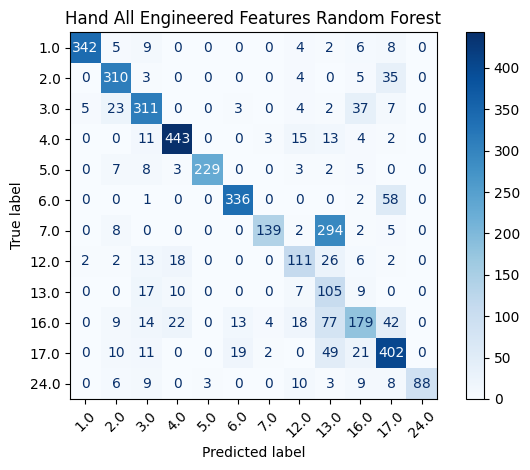


chest: loaded 107 Protocol segments


Windowing chest:   0%|          | 0/107 [00:00<?, ?it/s]

Number of filtered instances in the list: 30101
chest: processed windows (30101, 4)


Features chest:   0%|          | 0/30101 [00:00<?, ?it/s]


Chest All Engineered Features Random Forest
  Accuracy:  0.8079
  Precision: 0.8418
  Recall:    0.8079
  F1-Score:  0.8131
              precision    recall  f1-score   support

         1.0       1.00      0.95      0.98       376
         2.0       0.76      0.80      0.78       357
         3.0       0.51      0.81      0.63       392
         4.0       0.91      0.58      0.71       491
         5.0       1.00      0.89      0.94       257
         6.0       0.98      0.83      0.90       397
         7.0       0.69      0.92      0.79       450
        12.0       0.84      0.77      0.80       180
        13.0       0.77      0.82      0.79       148
        16.0       0.84      0.84      0.84       378
        17.0       0.89      0.78      0.83       514
        24.0       1.00      0.74      0.85       136

    accuracy                           0.81      4076
   macro avg       0.85      0.81      0.82      4076
weighted avg       0.84      0.81      0.81      4076



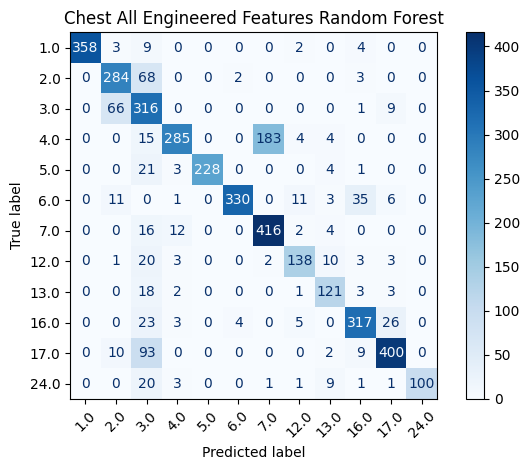


ankle: loaded 107 Protocol segments


Windowing ankle:   0%|          | 0/107 [00:00<?, ?it/s]

Number of filtered instances in the list: 30101
ankle: processed windows (30101, 4)


Features ankle:   0%|          | 0/30101 [00:00<?, ?it/s]


Ankle All Engineered Features Random Forest
  Accuracy:  0.6909
  Precision: 0.7040
  Recall:    0.6909
  F1-Score:  0.6900
              precision    recall  f1-score   support

         1.0       0.99      0.94      0.97       376
         2.0       0.63      0.90      0.74       357
         3.0       0.46      0.37      0.41       392
         4.0       0.63      0.58      0.60       491
         5.0       0.87      0.86      0.87       257
         6.0       0.98      0.86      0.92       397
         7.0       0.59      0.58      0.59       450
        12.0       0.77      0.71      0.74       180
        13.0       0.75      0.76      0.76       148
        16.0       0.50      0.74      0.60       378
        17.0       0.66      0.57      0.61       514
        24.0       0.90      0.51      0.65       136

    accuracy                           0.69      4076
   macro avg       0.73      0.70      0.70      4076
weighted avg       0.70      0.69      0.69      4076



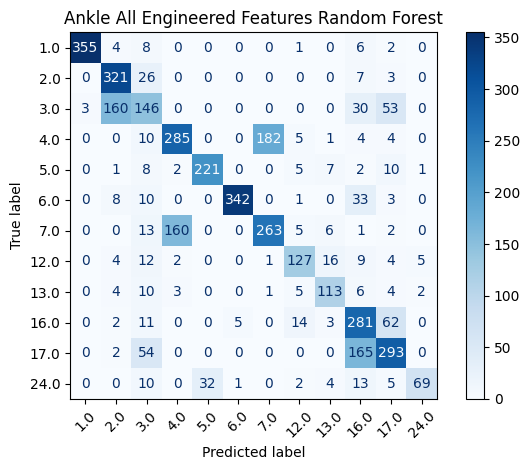


SENSOR CONFIGURATION COMPARISON
                                   Approach  Accuracy  Precision   Recall  F1-Score Sensor  Train Windows  Test Windows  Features
Chest All Engineered Features Random Forest  0.807900   0.841797 0.807900  0.813133  chest          26025          4076       112
 Hand All Engineered Features Random Forest  0.734789   0.811960 0.734789  0.747188   hand          26025          4076       112
Ankle All Engineered Features Random Forest  0.690873   0.703960 0.690873  0.690029  ankle          26025          4076       112


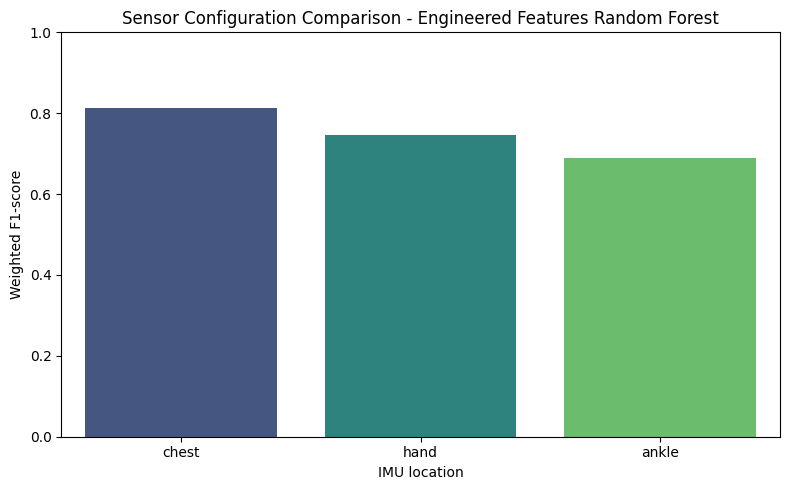

In [67]:
RUN_SENSOR_COMPARISON = True


def build_processed_instances_for_sensor(imu_location):
    sensor_query = {"split": "Protocol", "imu_location": imu_location, "sensor": "AccGyr"}
    sensor_documents = list(coll.find(sensor_query))
    print(f"\n{imu_location}: loaded {len(sensor_documents)} Protocol segments")

    sensor_windowed_instances = []
    for doc in tqdm_notebook(sensor_documents, desc=f"Windowing {imu_location}"):
        df_segment = pd.DataFrame(doc["data"])
        windows = sliding_window_pd(
            df_segment,
            ws=window_size,
            overlap=step,
            w_type=config["sliding_window"]["w_type"],
            w_center=config["sliding_window"]["w_center"],
            print_stats=False,
        )
        for window in windows:
            sensor_windowed_instances.append({
                "window": window,
                "activity_label": doc["activity_label"],
                "activity_id": doc["activity_id"],
                "subject": doc["subject"],
            })

    sensor_filtered_windows = filter_instances(
        [item["window"] for item in sensor_windowed_instances],
        order=config["filter"]["order"],
        wn=config["filter"]["wn"],
        filter_type=config["filter"]["type"],
    )

    sensor_processed = pd.DataFrame([
        {
            "activity_label": sensor_windowed_instances[i]["activity_label"],
            "activity_id": sensor_windowed_instances[i]["activity_id"],
            "subject": sensor_windowed_instances[i]["subject"],
            "window": compute_magnitude(sensor_filtered_windows[i]),
        }
        for i in range(len(sensor_filtered_windows))
    ])
    print(f"{imu_location}: processed windows {sensor_processed.shape}")
    return sensor_processed


def build_feature_table_for_sensor(sensor_processed, imu_location):
    rows = []
    for _, inst in tqdm_notebook(sensor_processed.iterrows(), total=len(sensor_processed), desc=f"Features {imu_location}"):
        features = extract_window_features(inst["window"], sr=100)
        features["activity_id"] = inst["activity_id"]
        features["activity_label"] = inst["activity_label"]
        features["subject"] = inst["subject"]
        rows.append(features)
    return pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna()


def evaluate_sensor_configuration(imu_location):
    sensor_processed = build_processed_instances_for_sensor(imu_location)
    sensor_features = build_feature_table_for_sensor(sensor_processed, imu_location)

    feature_cols_sensor = [col for col in sensor_features.columns if col not in metadata_cols]
    train_mask_sensor = sensor_features["subject"].isin(TRAIN_SUBJECTS)
    test_mask_sensor = sensor_features["subject"].isin(TEST_SUBJECTS)

    X_train_sensor = sensor_features.loc[train_mask_sensor, feature_cols_sensor]
    X_test_sensor = sensor_features.loc[test_mask_sensor, feature_cols_sensor]
    y_train_sensor = sensor_features.loc[train_mask_sensor, "activity_id"].to_numpy()
    y_test_sensor = sensor_features.loc[test_mask_sensor, "activity_id"].to_numpy()

    scaler_sensor = StandardScaler()
    X_train_sensor_scaled = scaler_sensor.fit_transform(X_train_sensor)
    X_test_sensor_scaled = scaler_sensor.transform(X_test_sensor)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        class_weight="balanced_subsample",
        random_state=42,
    )
    model.fit(X_train_sensor_scaled, y_train_sensor)

    rows = []
    labels = sorted(np.unique(np.concatenate([y_train_sensor, y_test_sensor])))
    evaluate_model(
        f"{imu_location.title()} All Engineered Features Random Forest",
        model,
        X_test_sensor_scaled,
        y_test_sensor,
        rows,
        labels=labels,
        save_cm=f"cm_sensor_{imu_location}_all_features_random_forest.png",
    )
    rows[0]["Sensor"] = imu_location
    rows[0]["Train Windows"] = len(y_train_sensor)
    rows[0]["Test Windows"] = len(y_test_sensor)
    rows[0]["Features"] = len(feature_cols_sensor)
    return rows[0]


if RUN_SENSOR_COMPARISON:
    sensor_results = []
    for imu_location in ["hand", "chest", "ankle"]:
        sensor_results.append(evaluate_sensor_configuration(imu_location))

    sensor_results_df = pd.DataFrame(sensor_results).sort_values("F1-Score", ascending=False)
    print("\nSENSOR CONFIGURATION COMPARISON")
    print(sensor_results_df.to_string(index=False))
    sensor_results_df.to_csv(RESULTS_DIR / "sensor_comparison_protocol_accgyr_random_forest.csv", index=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=sensor_results_df, x="Sensor", y="F1-Score", hue="Sensor", palette="viridis", legend=False)
    plt.ylim(0, 1)
    plt.title("Sensor Configuration Comparison - Engineered Features Random Forest")
    plt.ylabel("Weighted F1-score")
    plt.xlabel("IMU location")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "sensor_comparison_protocol_accgyr_random_forest.png", bbox_inches="tight")
    plt.show()
else:
    print("Sensor comparison skipped. Set RUN_SENSOR_COMPARISON = True to run wrist/chest/ankle comparison.")

### Apply optimization with Grid Search and/or Cross-validation

In [68]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [69]:
def run_grid_search(name, model, param_grid, X_train, y_train, cv, verbose):
    print(f"\n GRID SEARCH: {name}\n")

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=config["fine_tune"]["grid_search"]["scoring"],
        refit=True,
        cv=cv,
        verbose=verbose,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("\nBEST RESULT")
    print("Params:", grid.best_params_)
    print("F1:", round(grid.best_score_, 4))

    return grid


### Evaluate optimized classifier

Once you are satisfied with the wrist-only configuration, repeat the **load → process → train → evaluate** flow for the chest and ankle IMUs (and combinations thereof) and compare the metrics in your report.

--- Starting Grid Search: Engineered Features Only ---
Feature Dimension: 336 (Engineered)

 GRID SEARCH: Engineered_Combined_SVC

Fitting 5 folds for each of 9 candidates, totalling 45 fits

BEST RESULT
Params: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
F1: 0.8956

[Best SVC - Engineered Model] Parameters: {'C': 1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

         1.0       0.88      0.95      0.92       376
         2.0       0.79      0.69      0.73       357
         3.0       0.45      0.91      0.61       392
         4.0       0.64      0.94      0.76       491
         5.0       0.93      0.88      0.91       257
         6.0       0.96      0.93      0.95       397
         7.0       0.00      0.00      0.00       450
        12.0       0.72      0.79      0.76       180
        13.0       0.37      0.78      0.51       148
        16.0       0.72      0.88      0.79      

/home/manousos_kirkinis/miniconda3/envs/aegis_env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



BEST RESULT
Params: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 800}
F1: 0.9014

[Best RandomForest - Engineered Model] Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 800}
              precision    recall  f1-score   support

         1.0       1.00      0.94      0.97       376
         2.0       0.88      0.95      0.91       357
         3.0       0.69      0.88      0.77       392
         4.0       0.97      0.96      0.97       491
         5.0       1.00      0.89      0.94       257
         6.0       0.99      0.94      0.97       397
         7.0       1.00      0.94      0.97       450
        12.0       0.95      0.76      0.85       180
        13.0       0.80      0.80      0.80       148
        16.0       0.86      0.90      0.88       378
        17.0       0.91      0.93      0.92       514
        24.0       

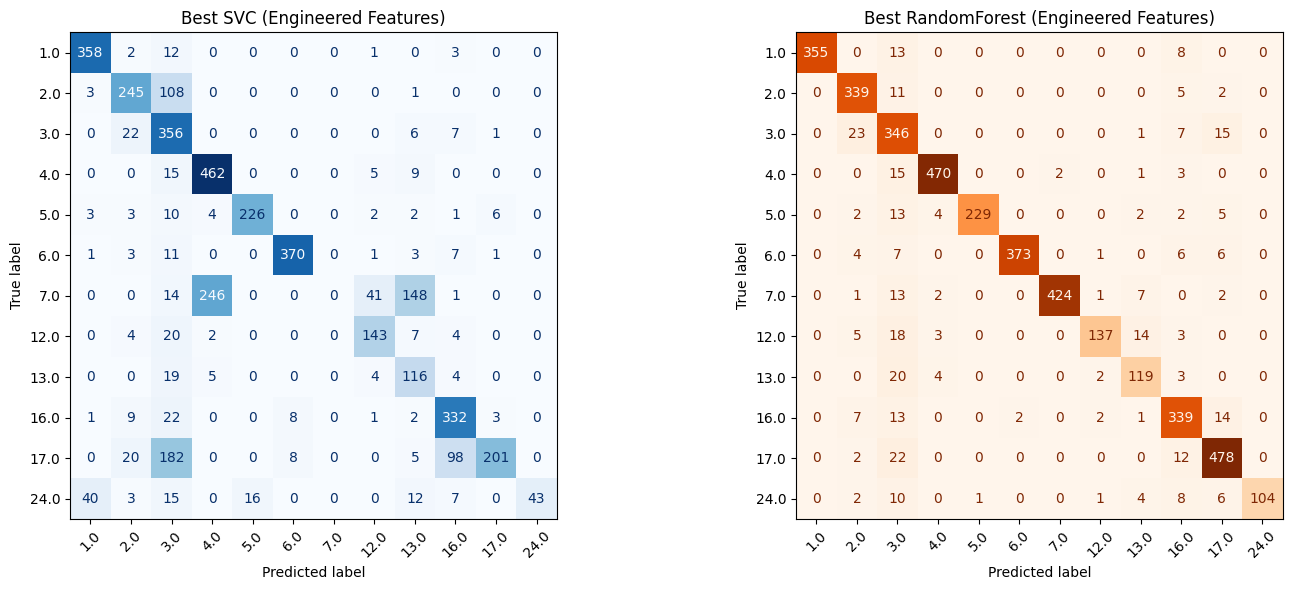

In [70]:
# --- Configuration Toggle ---
RUN_GRID_SEARCH = True
USE_PCA_FUSION = False # Set to True to include PCA features, False for engineered only
RUN_COMBINED_SENSOR_MODEL = True

if RUN_GRID_SEARCH and RUN_COMBINED_SENSOR_MODEL:
    
    # 1. & 2. Feature Preparation Logic
    if USE_PCA_FUSION:
        print(f"--- Starting Grid Search: Fused (Engineered + PCA) ---")
        pca_engine = PCA(n_components=n_components_95, random_state=42)
        X_train_pca = pca_engine.fit_transform(X_train_combined_scaled)
        X_test_pca = pca_engine.transform(X_test_combined_scaled)
        
        # FEATURE FUSION
        X_train_final = np.hstack((X_train_combined_scaled, X_train_pca))
        X_test_final = np.hstack((X_test_combined_scaled, X_test_pca))
        mode_label = "Fused"
    else:
        print(f"--- Starting Grid Search: Engineered Features Only ---")
        X_train_final = X_train_combined_scaled
        X_test_final = X_test_combined_scaled
        mode_label = "Engineered"
    
    print(f"Feature Dimension: {X_train_final.shape[1]} ({mode_label})")

    # 3. Define targets
    targets = [
        {"name": "SVC", "model": SVC(random_state=42), "cmap": plt.cm.Blues},
        {"name": "RandomForest", "model": RandomForestClassifier(random_state=42), "cmap": plt.cm.Oranges}
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for i, t in enumerate(targets):
        model_cfg = config["fine_tune"][t["name"]]
        
        # Run search
        grid = run_grid_search(
            name=f"{mode_label}_Combined_{t['name']}",
            model=t["model"],
            param_grid=model_cfg["param_grid"],
            X_train=X_train_final,
            y_train=y_train_combined,
            cv=model_cfg["cv"],
            verbose=1,
        )

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_final)

        print(f"\n[Best {t['name']} - {mode_label} Model] Parameters: {grid.best_params_}")
        print(classification_report(y_test_combined, y_pred, zero_division=0))

        # Plot
        cm = confusion_matrix(y_test_combined, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=combined_label_order)
        disp.plot(cmap=t["cmap"], ax=axes[i], colorbar=False, xticks_rotation=45)
        axes[i].set_title(f"Best {t['name']} ({mode_label} Features)")

    plt.tight_layout()
    # Dynamic filename based on choice
    plt.savefig(RESULTS_DIR / f"cm_grid_{mode_label.lower()}_combined.png", bbox_inches="tight")
    plt.show()

elif not RUN_GRID_SEARCH:
    print("Grid Search flag is False. Skipping.")
else:
    print("Combined model variables missing. Check RUN_COMBINED_SENSOR_MODEL.")